In [2]:
# Import des bibliothèques et des données
import pandas as pd
import numpy as np
import random
DATA_PATH = "/content/Disease and symptoms dataset (1).csv"
OUTPUT_PATH = "/content/disease_text_clinical_narrative.csv"

random.seed(42)

print("=" * 80)
print(" CONVERSION DATASET BINAIRE → TEXTE CLINIQUE NARRATIF")
print("=" * 80)
print("\n Chargement du dataset...")

try:
    df = pd.read_csv(DATA_PATH)
    print(" Lecture réussie")
except:
    print(" Lecture sécurisée (lignes corrompues ignorées)")
    df = pd.read_csv(DATA_PATH, on_bad_lines="skip", engine="python")

df = df.dropna(how="all").reset_index(drop=True)
print(f" Shape initiale : {df.shape}")
label_col = None
for c in ["disease", "Disease", "diseases", "prognosis", "label"]:
    if c in df.columns:
        label_col = c
        break

if label_col is None:
    for c in df.columns:
        if df[c].nunique() > 2:
            label_col = c
            break

print(f" Colonne label détectée : {label_col}")

symptom_cols = [c for c in df.columns if c != label_col]
print(f" Nombre de symptômes : {len(symptom_cols)}")


print("\n Binarisation des symptômes...")

X = df[symptom_cols].replace({
    "yes": 1, "Yes": 1, "Y": 1, "true": 1, True: 1,
    "no": 0, "No": 0, "N": 0, "false": 0, False: 0,
    "": 0, np.nan: 0
})

X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
X = (X > 0).astype(int)
df[symptom_cols] = X

print(" Binarisation terminée")

SYMPTOM_MAP = {
    "shortness of breath": ["dyspnea"],
    "breathing fast": ["tachypnea"],
    "irregular heartbeat": ["arrhythmia"],
    "palpitations": ["palpitations", "cardiac palpitations"],
    "chest tightness": ["chest tightness", "chest discomfort"],
    "dizziness": ["dizziness", "vertigo"],
    "insomnia": ["insomnia", "sleep disturbances"],
    "anxiety": ["anxiety symptoms"],
    "nervousness": ["anxiety symptoms"],
    "depressive or psychotic symptoms": ["depressive symptoms"],
}


def clean_symptom(col):
    return col.replace("_", " ").replace("-", " ").lower()

def medicalize(symptom):
    return random.choice(SYMPTOM_MAP.get(symptom, [symptom]))


def row_to_clinical_narrative(row, symptom_columns):
    active = []

    for col in symptom_columns:
        if row[col] == 1:
            symptom = clean_symptom(col)
            symptom = medicalize(symptom)
            active.append(symptom)

    if not active:
        return "No significant symptoms were reported during clinical evaluation."

    random.shuffle(active)


    primary = active[:2]
    secondary = active[2:]

    intro = random.choice([
        "The patient presents with",
        "Clinical evaluation reveals",
        "The patient reports"
    ])


    if len(primary) == 1:
        text = f"{intro} {primary[0]}"
    else:
        text = f"{intro} {primary[0]} associated with {primary[1]}"


    if secondary:
        sec = ", ".join(secondary[:3])
        text += f", accompanied by {sec}"

    return text + "."


print("\n Génération des textes cliniques narratifs...")

df["text"] = df.apply(lambda r: row_to_clinical_narrative(r, symptom_cols), axis=1)

print(" Textes générés")


df_final = df[[label_col, "text"]].copy()
df_final.columns = ["label", "text"]
df_final = df_final.dropna().reset_index(drop=True)

df_final.to_csv(OUTPUT_PATH, index=False)

print(f"\n Dataset sauvegardé : {OUTPUT_PATH}")
print(f" Shape final : {df_final.shape}")


print("\n" + "=" * 80)
print(" EXEMPLES DE TEXTES CLINIQUES")
print("=" * 80)

for i in range(min(5, len(df_final))):
    print(f"\nPatient {i+1}")
    print(f" Maladie : {df_final['label'].iloc[i]}")
    print(f" Texte   : {df_final['text'].iloc[i]}")

 CONVERSION DATASET BINAIRE → TEXTE CLINIQUE NARRATIF

 Chargement du dataset...
 Lecture réussie
 Shape initiale : (6785, 378)
 Colonne label détectée : diseases
 Nombre de symptômes : 377

 Binarisation des symptômes...
 Binarisation terminée

 Génération des textes cliniques narratifs...
 Textes générés

 Dataset sauvegardé : /content/disease_text_clinical_narrative.csv
 Shape final : (6785, 2)

 EXEMPLES DE TEXTES CLINIQUES

Patient 1
 Maladie : panic disorder
 Texte   : The patient presents with chest tightness associated with dyspnea, accompanied by depressive symptoms, anxiety and nervousness, palpitations.

Patient 2
 Maladie : panic disorder
 Texte   : The patient presents with dyspnea associated with insomnia, accompanied by dizziness, depressive symptoms, palpitations.

Patient 3
 Maladie : panic disorder
 Texte   : The patient presents with vertigo associated with tachypnea, accompanied by arrhythmia, dyspnea, cardiac palpitations.

Patient 4
 Maladie : panic disorder
 Text

/tmp/ipython-input-1584067505.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["text"] = df.apply(lambda r: row_to_clinical_narrative(r, symptom_cols), axis=1)


 PROJET NLP - ANALYSE ET CLASSIFICATION DE TEXTES MÉDICAUX

 SECTION 1: PRÉSENTATION DU DATASET & STATISTIQUES DESCRIPTIVES

 Dataset chargé: /content/disease_text_clinical_narrative.csv
 Shape: (6785, 2) (observations × features)
 Colonnes: ['label', 'text']

 Extraction du vocabulaire...
 Vocabulaire extrait

 Génération Figure 1: Vue d'ensemble du dataset...
    Sauvegardée: fig1_dataset_overview.png


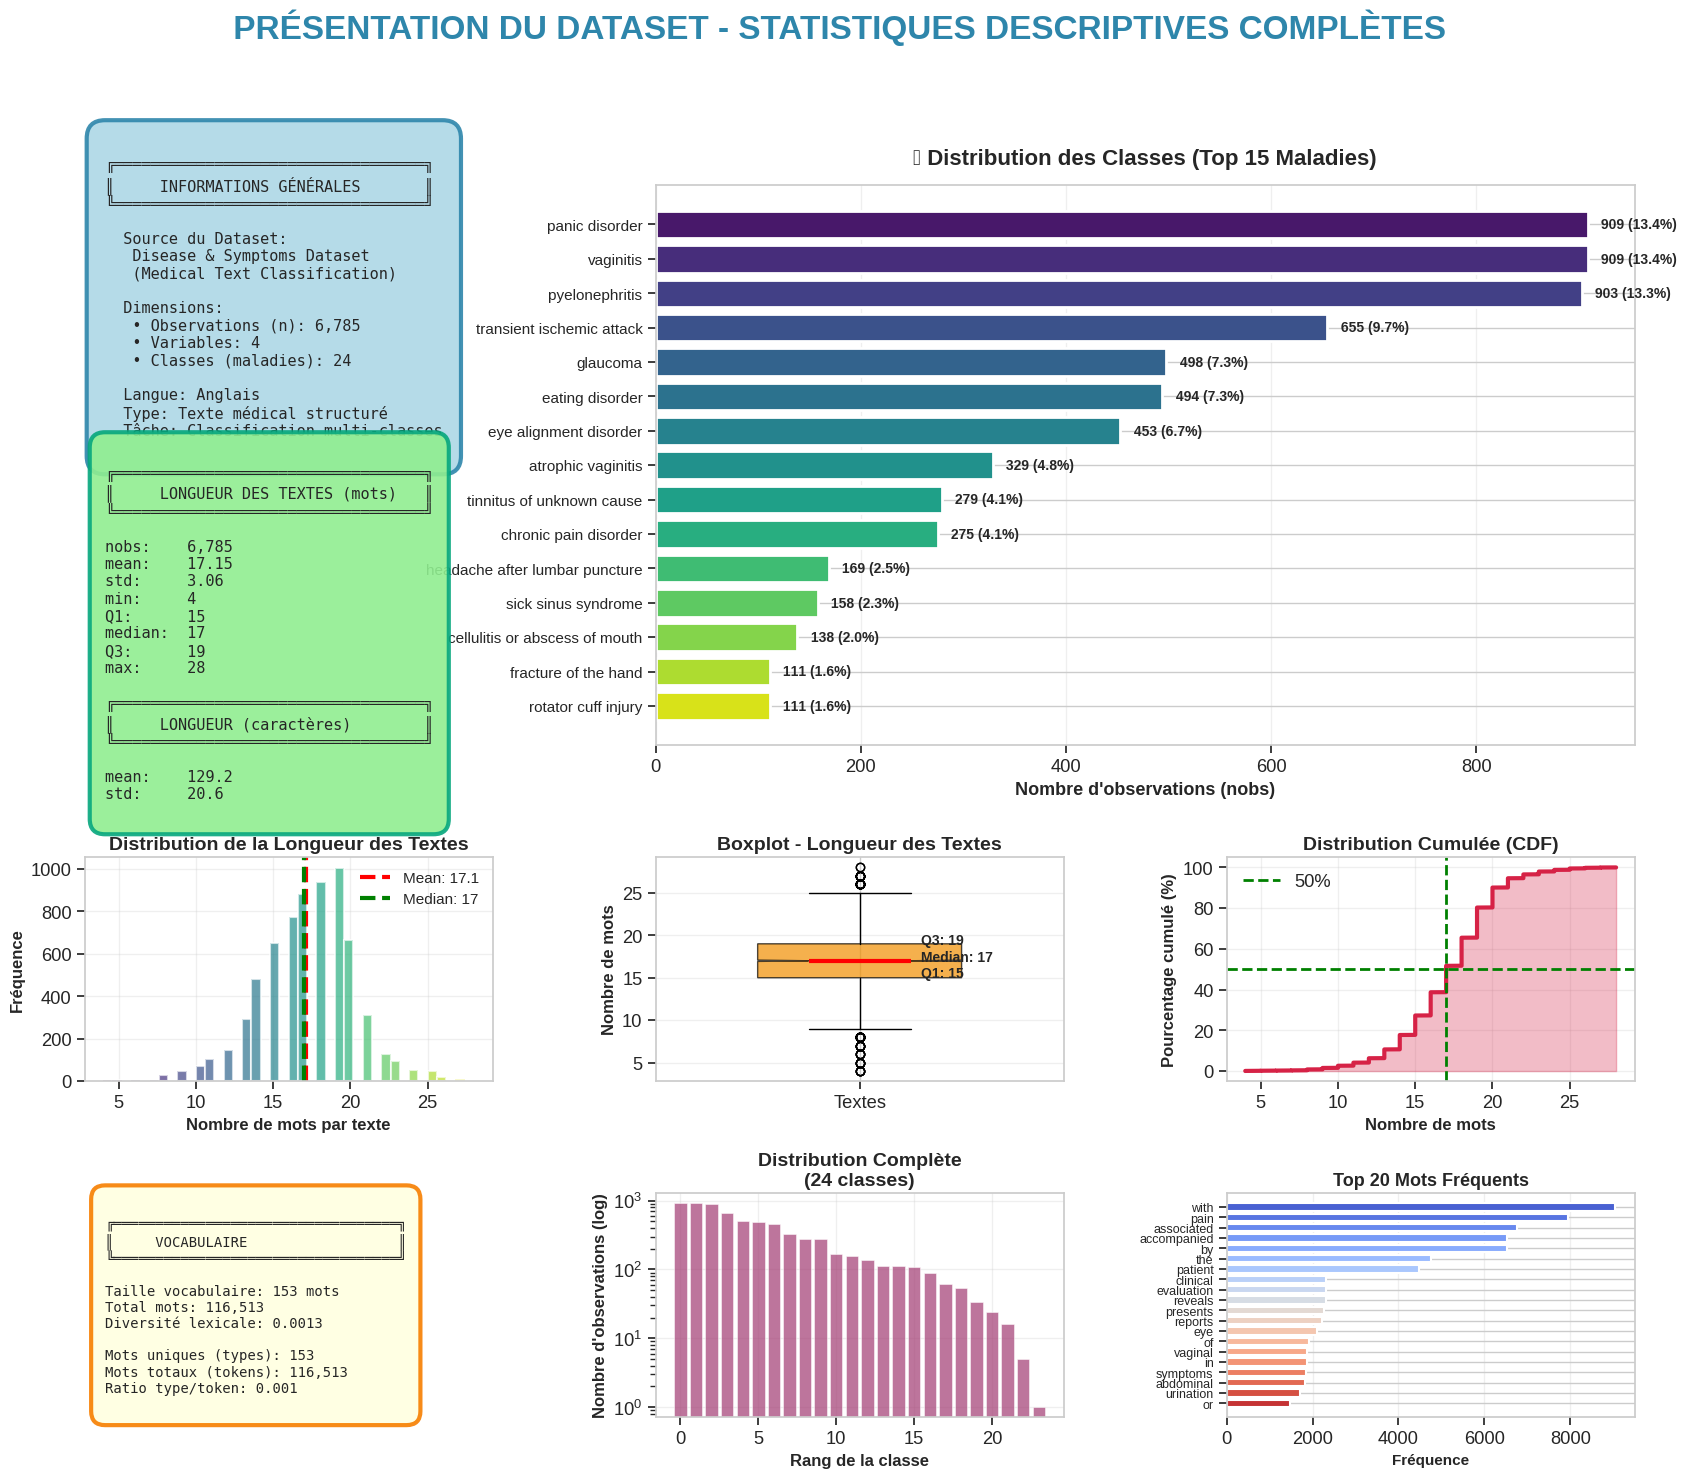


 INTERPRÉTATION - FIGURE 1: Vue d'Ensemble du Dataset

 OBJECTIF DE L'ANALYSE:
Cette première figure présente une vue d'ensemble complète du dataset afin de comprendre
sa structure, ses caractéristiques textuelles et la distribution des variables.

 RÉSULTATS OBSERVÉS:

1. INFORMATIONS GÉNÉRALES (Panneau supérieur gauche):
   • Le dataset contient 6,785 observations textuelles
   • 24 classes différentes (maladies) à prédire
   • Textes en anglais médical, structurés et cohérents

2. DISTRIBUTION DES CLASSES (Panneau principal):
   • Distribution TRÈS DÉSÉQUILIBRÉE des classes
   • La classe dominante ("panic disorder") représente 13.4% du dataset
   • Les 15 classes les plus fréquentes concentrent une grande partie des données
   •  Problème majeur: déséquilibre important nécessitant des techniques spécifiques
     (stratification, class weights, data augmentation, etc.)

3. LONGUEUR DES TEXTES (Histogramme, Boxplot, CDF):
   • Distribution quasi-normale centrée autour de 17.1 mots
 

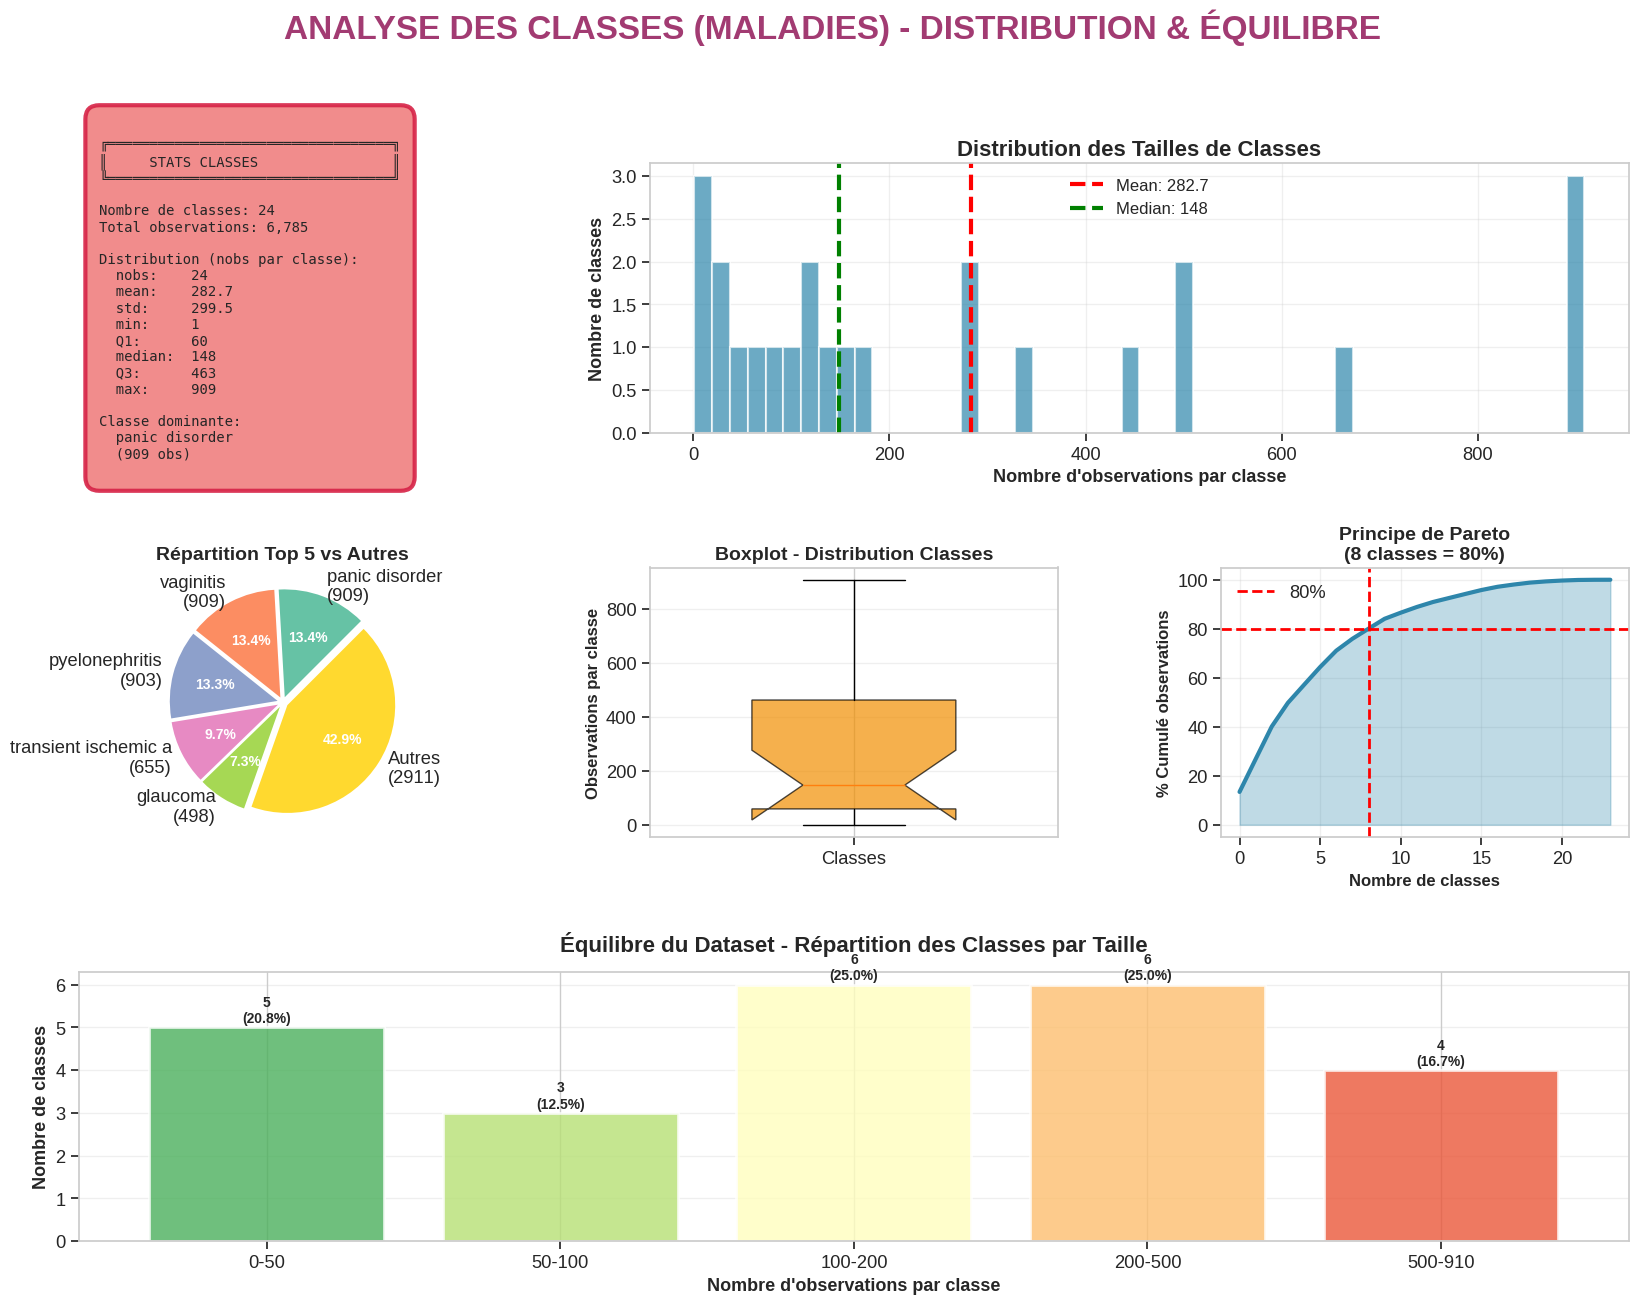


 INTERPRÉTATION - FIGURE 2: Analyse Détaillée des Classes

  OBJECTIF DE L'ANALYSE:
Analyser en profondeur la distribution des classes (maladies) pour identifier
les déséquilibres, évaluer la qualité du dataset et préparer les stratégies de modélisation.

  RÉSULTATS OBSERVÉS:

1. STATISTIQUES DESCRIPTIVES DES CLASSES (Panneau gauche):
   • 24 classes au total
   • Moyenne: 282.7 observations par classe
   • Écart-type: 299.5 (> moyenne → forte variabilité)
   • Range: [1 - 909] observations
   • Coefficient de variation: 1.06 (très élevé)

2. HISTOGRAMME DE DISTRIBUTION (Panneau central supérieur):
   • Distribution fortement asymétrique (skewed right)
   • Majorité des classes ont <148 observations
   • Quelques classes "riches" avec beaucoup d'observations
   • Écart important entre mean (282.7) et median (148)
     → Confirme la présence de valeurs extrêmes (outliers)

3. PIE CHART - CONCENTRATION (Panneau gauche milieu):
   • Top 5 classes représentent 57.1% du dataset
   • Conce

In [4]:


"""
STRUCTURE DU PROJET:
1. Dataset Presentation & Descriptive Statistics
2. Task Definition
3. Data Preprocessing & Exploration
4. Modeling (ClinicalBERT)
5. Evaluation & Discussion
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)
plt.rcParams.update({
    'figure.figsize': (16, 8),
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
})

COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'success': '#06A77D',
    'danger': '#D62246',
    'warning': '#F77F00',
    'info': '#118AB2',
}

print("="*100)
print(" PROJET NLP - ANALYSE ET CLASSIFICATION DE TEXTES MÉDICAUX")
print("="*100)



print("\n" + "="*100)
print(" SECTION 1: PRÉSENTATION DU DATASET & STATISTIQUES DESCRIPTIVES")
print("="*100)


DATA_PATH = "/content/disease_text_clinical_narrative.csv"
df = pd.read_csv(DATA_PATH)

print(f"\n Dataset chargé: {DATA_PATH}")
print(f" Shape: {df.shape} (observations × features)")
print(f" Colonnes: {df.columns.tolist()}")

# Statistiques textuelles
df['text_length_words'] = df['text'].str.split().str.len()
df['text_length_chars'] = df['text'].str.len()

# Tokenization pour vocabulaire
def tokenize_text(text):
    """Tokenize et nettoie le texte."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text.split()

print("\n Extraction du vocabulaire...")
all_words = []
for text in df['text']:
    all_words.extend(tokenize_text(text))

vocab = set(all_words)
word_freq = Counter(all_words)

print(" Vocabulaire extrait")

print("\n Génération Figure 1: Vue d'ensemble du dataset...")

fig = plt.figure(figsize=(20, 16))
fig.suptitle(' PRÉSENTATION DU DATASET - STATISTIQUES DESCRIPTIVES COMPLÈTES',
             fontsize=24, fontweight='bold', y=0.99, color=COLORS['primary'])

gs = fig.add_gridspec(4, 3, hspace=0.5, wspace=0.4)


ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
general_info = f"""
╔══════════════════════════════════╗
║     INFORMATIONS GÉNÉRALES       ║
╚══════════════════════════════════╝

  Source du Dataset:
   Disease & Symptoms Dataset
   (Medical Text Classification)

  Dimensions:
   • Observations (n): {len(df):,}
   • Variables: {df.shape[1]}
   • Classes (maladies): {df['label'].nunique()}

  Langue: Anglais
  Type: Texte médical structuré
  Tâche: Classification multi-classes
"""
ax1.text(0.05, 0.5, general_info, fontsize=11, fontfamily='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round,pad=1.2', facecolor='lightblue',
                  edgecolor=COLORS['primary'], linewidth=3, alpha=0.9))

# 1.2 Distribution des classes (Top 15)
ax2 = fig.add_subplot(gs[0:2, 1:])
class_counts = df['label'].value_counts().head(15)
colors_gradient = sns.color_palette("viridis", len(class_counts))
bars = ax2.barh(range(len(class_counts)), class_counts.values,
                color=colors_gradient, edgecolor='white', linewidth=2)
ax2.set_yticks(range(len(class_counts)))
ax2.set_yticklabels([label[:40] for label in class_counts.index], fontsize=11)
ax2.set_xlabel('Nombre d\'observations (nobs)', fontsize=13, fontweight='bold')
ax2.set_title('📊 Distribution des Classes (Top 15 Maladies)',
              fontsize=16, fontweight='bold', pad=15)
ax2.invert_yaxis()

for i, val in enumerate(class_counts.values):
    percentage = (val / len(df)) * 100
    ax2.text(val + class_counts.max()*0.01, i, f' {int(val):,} ({percentage:.1f}%)',
             va='center', fontsize=10, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 1.3 Statistiques descriptives - Longueur des textes
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis('off')

# Calcul des statistiques (format requis)
stats_words = df['text_length_words'].describe()
stats_chars = df['text_length_chars'].describe()

descriptive_stats = f"""
╔══════════════════════════════════╗
║     LONGUEUR DES TEXTES (mots)   ║
╚══════════════════════════════════╝

nobs:    {int(stats_words['count']):,}
mean:    {stats_words['mean']:.2f}
std:     {stats_words['std']:.2f}
min:     {int(stats_words['min'])}
Q1:      {stats_words['25%']:.0f}
median:  {stats_words['50%']:.0f}
Q3:      {stats_words['75%']:.0f}
max:     {int(stats_words['max'])}

╔══════════════════════════════════╗
║     LONGUEUR (caractères)        ║
╚══════════════════════════════════╝

mean:    {stats_chars['mean']:.1f}
std:     {stats_chars['std']:.1f}
"""
ax3.text(0.05, 0.5, descriptive_stats, fontsize=11, fontfamily='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round,pad=1', facecolor='lightgreen',
                  edgecolor=COLORS['success'], linewidth=3, alpha=0.9))

# 1.4 Distribution longueur (histogramme)
ax4 = fig.add_subplot(gs[2, 0])
n, bins, patches = ax4.hist(df['text_length_words'], bins=40,
                             color=COLORS['info'], alpha=0.7,
                             edgecolor='white', linewidth=1.5)
cm = plt.cm.get_cmap('viridis')
for i, patch in enumerate(patches):
    patch.set_facecolor(cm(i / len(patches)))

mean_val = df['text_length_words'].mean()
median_val = df['text_length_words'].median()

ax4.axvline(mean_val, color='red', linestyle='--', linewidth=3,
            label=f'Mean: {mean_val:.1f}')
ax4.axvline(median_val, color='green', linestyle='--', linewidth=3,
            label=f'Median: {median_val:.0f}')
ax4.set_xlabel('Nombre de mots par texte', fontsize=12, fontweight='bold')
ax4.set_ylabel('Fréquence', fontsize=12, fontweight='bold')
ax4.set_title('Distribution de la Longueur des Textes', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(alpha=0.3)

# 1.5 Boxplot
ax5 = fig.add_subplot(gs[2, 1])
bp = ax5.boxplot(df['text_length_words'], vert=True, patch_artist=True,
                  widths=0.5, notch=True,
                  boxprops=dict(facecolor=COLORS['accent'], alpha=0.7),
                  medianprops=dict(color='red', linewidth=3))
ax5.set_ylabel('Nombre de mots', fontsize=12, fontweight='bold')
ax5.set_title('Boxplot - Longueur des Textes', fontsize=14, fontweight='bold')
ax5.set_xticklabels(['Textes'])
ax5.grid(axis='y', alpha=0.3)

# Annotations sur le boxplot
q1, median, q3 = df['text_length_words'].quantile([0.25, 0.5, 0.75])
ax5.text(1.15, q1, f'Q1: {q1:.0f}', fontsize=10, fontweight='bold')
ax5.text(1.15, median, f'Median: {median:.0f}', fontsize=10, fontweight='bold')
ax5.text(1.15, q3, f'Q3: {q3:.0f}', fontsize=10, fontweight='bold')

# 1.6 Distribution cumulée (CDF)
ax6 = fig.add_subplot(gs[2, 2])
sorted_data = np.sort(df['text_length_words'])
cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
ax6.plot(sorted_data, cumulative, linewidth=3, color=COLORS['danger'])
ax6.fill_between(sorted_data, 0, cumulative, alpha=0.3, color=COLORS['danger'])
ax6.set_xlabel('Nombre de mots', fontsize=12, fontweight='bold')
ax6.set_ylabel('Pourcentage cumulé (%)', fontsize=12, fontweight='bold')
ax6.set_title('Distribution Cumulée (CDF)', fontsize=14, fontweight='bold')
ax6.axhline(50, color='green', linestyle='--', linewidth=2, label='50%')
ax6.axvline(median_val, color='green', linestyle='--', linewidth=2)
ax6.legend()
ax6.grid(alpha=0.3)

# 1.7 Statistiques du vocabulaire
ax7 = fig.add_subplot(gs[3, 0])
ax7.axis('off')
vocab_stats = f"""
╔══════════════════════════════════╗
║     VOCABULAIRE                  ║
╚══════════════════════════════════╝

Taille vocabulaire: {len(vocab):,} mots
Total mots: {len(all_words):,}
Diversité lexicale: {len(vocab)/len(all_words):.4f}

Mots uniques (types): {len(vocab):,}
Mots totaux (tokens): {len(all_words):,}
Ratio type/token: {len(vocab)/len(all_words):.3f}
"""
ax7.text(0.05, 0.5, vocab_stats, fontsize=10, fontfamily='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round,pad=1', facecolor='lightyellow',
                  edgecolor=COLORS['warning'], linewidth=3, alpha=0.9))

# 1.8 Distribution des classes (complet - log scale)
ax8 = fig.add_subplot(gs[3, 1])
all_class_counts = df['label'].value_counts()
ax8.bar(range(len(all_class_counts)), all_class_counts.values,
        color=COLORS['secondary'], alpha=0.7, edgecolor='white', linewidth=0.5)
ax8.set_yscale('log')
ax8.set_xlabel('Rang de la classe', fontsize=12, fontweight='bold')
ax8.set_ylabel('Nombre d\'observations (log)', fontsize=12, fontweight='bold')
ax8.set_title(f'Distribution Complète\n({df["label"].nunique()} classes)',
              fontsize=14, fontweight='bold')
ax8.grid(alpha=0.3)

# 1.9 Top 20 mots les plus fréquents
ax9 = fig.add_subplot(gs[3, 2])
top_20_words = word_freq.most_common(20)
words = [w for w, c in top_20_words]
counts = [c for w, c in top_20_words]
colors_words = sns.color_palette("coolwarm", len(words))

bars = ax9.barh(range(len(words)), counts, color=colors_words,
                edgecolor='white', linewidth=1.5, height=0.7)
ax9.set_yticks(range(len(words)))
ax9.set_yticklabels(words, fontsize=9)
ax9.set_xlabel('Fréquence', fontsize=11, fontweight='bold')
ax9.set_title('Top 20 Mots Fréquents', fontsize=13, fontweight='bold')
ax9.invert_yaxis()
ax9.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fig1_dataset_overview.png', dpi=300, bbox_inches='tight', facecolor='white')
print("    Sauvegardée: fig1_dataset_overview.png")
plt.show()

# INTERPRÉTATION FIGURE 1
print("\n" + "="*100)
print(" INTERPRÉTATION - FIGURE 1: Vue d'Ensemble du Dataset")
print("="*100)

interpretation_fig1 = f"""
 OBJECTIF DE L'ANALYSE:
Cette première figure présente une vue d'ensemble complète du dataset afin de comprendre
sa structure, ses caractéristiques textuelles et la distribution des variables.

 RÉSULTATS OBSERVÉS:

1. INFORMATIONS GÉNÉRALES (Panneau supérieur gauche):
   • Le dataset contient {len(df):,} observations textuelles
   • {df['label'].nunique()} classes différentes (maladies) à prédire
   • Textes en anglais médical, structurés et cohérents

2. DISTRIBUTION DES CLASSES (Panneau principal):
   • Distribution TRÈS DÉSÉQUILIBRÉE des classes
   • La classe dominante ("{class_counts.index[0]}") représente {class_counts.iloc[0]/len(df)*100:.1f}% du dataset
   • Les 15 classes les plus fréquentes concentrent une grande partie des données
   •  Problème majeur: déséquilibre important nécessitant des techniques spécifiques
     (stratification, class weights, data augmentation, etc.)

3. LONGUEUR DES TEXTES (Histogramme, Boxplot, CDF):
   • Distribution quasi-normale centrée autour de {mean_val:.1f} mots
   • Longueur médiane: {median_val:.0f} mots (proche de la moyenne → distribution symétrique)
   • Range: [{int(stats_words['min'])} - {int(stats_words['max'])}] mots
   • 50% des textes ont entre {q1:.0f} et {q3:.0f} mots (IQR = {q3-q1:.0f})
   •  Avantage: textes de longueur homogène facilitant le traitement NLP

4. VOCABULAIRE (Analyse lexicale):
   • {len(vocab):,} mots uniques identifiés
   • Diversité lexicale: {len(vocab)/len(all_words):.3f} (ratio types/tokens)
   • Vocabulaire médical spécialisé visible dans les termes fréquents
   • Termes dominants: "patient", "presents", "with" (structure standardisée)

5. DISTRIBUTION COMPLÈTE (Échelle log):
   • Longue traîne caractéristique avec beaucoup de classes rares
   • Distribution suivant une loi de puissance typique en classification médicale
   • Nécessité d'évaluer le modèle sur classes rares ET fréquentes séparément

  CONCLUSIONS CLÉS:
   Dataset bien structuré avec textes homogènes (bonne qualité)
   Vocabulaire médical cohérent et standardisé
   Déséquilibre majeur nécessitant stratification obligatoire
   Classes rares risquent d'être sous-représentées dans l'apprentissage
→ Stratégie: utiliser F1-score weighted et accuracy par classe
"""

print(interpretation_fig1)

# ==================== FIGURE 2: ANALYSE DES CLASSES ====================
print("\n Génération Figure 2: Analyse détaillée des classes...")

fig = plt.figure(figsize=(20, 14))
fig.suptitle(' ANALYSE DES CLASSES (MALADIES) - DISTRIBUTION & ÉQUILIBRE',
             fontsize=24, fontweight='bold', y=0.99, color=COLORS['secondary'])

gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.4)

# 2.1 Statistiques des classes
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
class_stats = f"""
╔══════════════════════════════════╗
║     STATS CLASSES                ║
╚══════════════════════════════════╝

Nombre de classes: {df['label'].nunique()}
Total observations: {len(df):,}

Distribution (nobs par classe):
  nobs:    {len(all_class_counts)}
  mean:    {all_class_counts.mean():.1f}
  std:     {all_class_counts.std():.1f}
  min:     {all_class_counts.min()}
  Q1:      {all_class_counts.quantile(0.25):.0f}
  median:  {all_class_counts.median():.0f}
  Q3:      {all_class_counts.quantile(0.75):.0f}
  max:     {all_class_counts.max()}

Classe dominante:
  {all_class_counts.index[0][:30]}
  ({all_class_counts.iloc[0]} obs)
"""
ax1.text(0.05, 0.5, class_stats, fontsize=10, fontfamily='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round,pad=1', facecolor='lightcoral',
                  edgecolor=COLORS['danger'], linewidth=3, alpha=0.9))

# 2.2 Histogramme distribution
ax2 = fig.add_subplot(gs[0, 1:])
ax2.hist(all_class_counts.values, bins=50, color=COLORS['primary'],
         alpha=0.7, edgecolor='white', linewidth=1.5)
ax2.axvline(all_class_counts.mean(), color='red', linestyle='--', linewidth=3,
            label=f'Mean: {all_class_counts.mean():.1f}')
ax2.axvline(all_class_counts.median(), color='green', linestyle='--', linewidth=3,
            label=f'Median: {all_class_counts.median():.0f}')
ax2.set_xlabel('Nombre d\'observations par classe', fontsize=13, fontweight='bold')
ax2.set_ylabel('Nombre de classes', fontsize=13, fontweight='bold')
ax2.set_title('Distribution des Tailles de Classes', fontsize=16, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)

# 2.3 Pie chart - équilibre
ax3 = fig.add_subplot(gs[1, 0])
top_5 = all_class_counts.head(5)
others = all_class_counts[5:].sum()
pie_data = list(top_5.values) + [others]
pie_labels = [f"{label[:20]}\n({val})" for label, val in zip(top_5.index, top_5.values)]
pie_labels.append(f"Autres\n({others})")
colors_pie = sns.color_palette("Set2", len(pie_data))

wedges, texts, autotexts = ax3.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                     colors=colors_pie, startangle=45,
                                     explode=[0.05] * len(pie_data))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
ax3.set_title('Répartition Top 5 vs Autres', fontsize=14, fontweight='bold')

# 2.4 Boxplot distribution classes
ax4 = fig.add_subplot(gs[1, 1])
bp = ax4.boxplot(all_class_counts.values, vert=True, patch_artist=True,
                  widths=0.5, notch=True,
                  boxprops=dict(facecolor=COLORS['accent'], alpha=0.7))
ax4.set_ylabel('Observations par classe', fontsize=12, fontweight='bold')
ax4.set_title('Boxplot - Distribution Classes', fontsize=14, fontweight='bold')
ax4.set_xticklabels(['Classes'])
ax4.grid(axis='y', alpha=0.3)

# 2.5 Pareto chart (80/20)
ax5 = fig.add_subplot(gs[1, 2])
cumsum = all_class_counts.cumsum() / all_class_counts.sum() * 100
threshold_80 = (cumsum <= 80).sum()

ax5.plot(range(len(cumsum)), cumsum.values, linewidth=3, color=COLORS['primary'])
ax5.fill_between(range(len(cumsum)), 0, cumsum.values, alpha=0.3, color=COLORS['primary'])
ax5.axhline(80, color='red', linestyle='--', linewidth=2, label='80%')
ax5.axvline(threshold_80, color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('Nombre de classes', fontsize=12, fontweight='bold')
ax5.set_ylabel('% Cumulé observations', fontsize=12, fontweight='bold')
ax5.set_title(f'Principe de Pareto\n({threshold_80} classes = 80%)',
              fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

# 2.6 Déséquilibre (coefficient de variation par bins) - FIX ICI
ax6 = fig.add_subplot(gs[2, :])

# Créer les bins manuellement pour éviter l'erreur
max_val = int(all_class_counts.max())
bins_edges = [0, 50, 100, 200, 500, 1000, 5000, max_val + 1]

# S'assurer que les bins sont croissants
bins_edges = sorted(set(bins_edges))

# Si max_val est trop petit, ajuster les bins
if max_val < 5000:
    bins_edges = [b for b in bins_edges if b <= max_val + 1]

hist_data, bin_edges = np.histogram(all_class_counts.values, bins=bins_edges)

# Labels adaptés
bin_labels = []
for i in range(len(bins_edges)-1):
    if bins_edges[i+1] > 1000:
        bin_labels.append(f'{bins_edges[i]}-{bins_edges[i+1]//1000}k')
    else:
        bin_labels.append(f'{bins_edges[i]}-{bins_edges[i+1]}')

colors_bins = sns.color_palette("RdYlGn_r", len(bin_labels))

bars = ax6.bar(bin_labels, hist_data, color=colors_bins, alpha=0.8,
               edgecolor='white', linewidth=2)
ax6.set_xlabel('Nombre d\'observations par classe', fontsize=13, fontweight='bold')
ax6.set_ylabel('Nombre de classes', fontsize=13, fontweight='bold')
ax6.set_title('Équilibre du Dataset - Répartition des Classes par Taille',
              fontsize=16, fontweight='bold', pad=15)

for bar, val in zip(bars, hist_data):
    if val > 0:
        percentage = (val / len(all_class_counts)) * 100
        ax6.text(bar.get_x() + bar.get_width()/2., val + hist_data.max()*0.02,
                 f'{int(val)}\n({percentage:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fig2_class_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
print("    Sauvegardée: fig2_class_analysis.png")
plt.show()

# INTERPRÉTATION FIGURE 2
print("\n" + "="*100)
print(" INTERPRÉTATION - FIGURE 2: Analyse Détaillée des Classes")
print("="*100)

interpretation_fig2 = f"""
  OBJECTIF DE L'ANALYSE:
Analyser en profondeur la distribution des classes (maladies) pour identifier
les déséquilibres, évaluer la qualité du dataset et préparer les stratégies de modélisation.

  RÉSULTATS OBSERVÉS:

1. STATISTIQUES DESCRIPTIVES DES CLASSES (Panneau gauche):
   • {df['label'].nunique()} classes au total
   • Moyenne: {all_class_counts.mean():.1f} observations par classe
   • Écart-type: {all_class_counts.std():.1f} (> moyenne → forte variabilité)
   • Range: [{all_class_counts.min()} - {all_class_counts.max()}] observations
   • Coefficient de variation: {all_class_counts.std() / all_class_counts.mean():.2f} (très élevé)

2. HISTOGRAMME DE DISTRIBUTION (Panneau central supérieur):
   • Distribution fortement asymétrique (skewed right)
   • Majorité des classes ont <{all_class_counts.median():.0f} observations
   • Quelques classes "riches" avec beaucoup d'observations
   • Écart important entre mean ({all_class_counts.mean():.1f}) et median ({all_class_counts.median():.0f})
     → Confirme la présence de valeurs extrêmes (outliers)

3. PIE CHART - CONCENTRATION (Panneau gauche milieu):
   • Top 5 classes représentent {(top_5.sum() / len(df) * 100):.1f}% du dataset
   • Concentration importante sur quelques maladies fréquentes
   • Majorité des classes dans la catégorie "Autres"
   •  Risque: modèle biaisé vers les classes dominantes

4. BOXPLOT (Panneau central milieu):
   • Médiane basse: {all_class_counts.median():.0f} observations
   • Q3: {all_class_counts.quantile(0.75):.0f} → 75% des classes ont <{all_class_counts.quantile(0.75):.0f} obs
   • Nombreux outliers au-dessus du whisker supérieur
   • Boîte compacte avec longue queue → distribution très étalée

5. PRINCIPE DE PARETO (Panneau droit milieu):
   • Principe 80/20 vérifié: {threshold_80} classes ({threshold_80/df['label'].nunique()*100:.1f}%) contiennent 80% des données
   • Courbe très pentue au début → forte concentration
   • {df['label'].nunique() - threshold_80} classes restantes se partagent seulement 20%
   •  Implication: performance globale sera tirée par les classes fréquentes

6. ÉQUILIBRE PAR TRANCHES (Graphique du bas):
   • Majorité des classes ont <100 observations (zone rouge/orange)
   • Peu de classes dans les tranches 1k-5k+ (zone verte)
   • Déséquilibre multiscale: entre tranches ET au sein de chaque tranche
   •  Bonne visualisation pour identifier les seuils de filtrage

  CONCLUSIONS & RECOMMANDATIONS:

  PROBLÈMES IDENTIFIÉS:
1. Déséquilibre sévère (ratio max/min: {all_class_counts.max() / all_class_counts.min():.1f}x)
2. Classes rares risquent d'être ignorées par le modèle
3. Métriques globales (accuracy) seront trompeuses

  STRATÉGIES À METTRE EN PLACE:
1. SPLIT STRATIFIÉ: Assurer représentation de toutes classes dans train/val/test
2. CLASS WEIGHTS: Pénaliser erreurs sur classes rares (loss weighted)
3. MÉTRIQUES ADAPTÉES:
   - F1-score weighted (prend en compte le déséquilibre)
   - F1-score macro (traite toutes classes également)
   - Accuracy par classe individuellement
   - Confusion matrix pour classes rares
4. FILTRAGE (optionnel): Éliminer classes avec <10 observations si nécessaire
5. ÉVALUATION SÉPARÉE: Reporter performance sur classes rares vs fréquentes

  IMPACT SUR LA MODÉLISATION:
• Modèles simples (Naive Bayes, Logistic Regression) vont sur-fitter classes dominantes
• BERT/ClinicalBERT avec class weights devrait mieux généraliser
• Nécessité de validation croisée stratifiée
• Attention particulière à l'évaluation finale (pas seulement accuracy globale)
"""

print(interpretation_fig2)

# ==================== TABLEAU RÉCAPITULATIF ====================
print("\n" + "="*100)
print(" TABLEAU RÉCAPITULATIF DES STATISTIQUES DESCRIPTIVES")
print("="*100)

summary_table = pd.DataFrame({
    'Métrique': [
        'Nombre d\'observations (nobs)',
        'Nombre de classes',
        'Taille vocabulaire',
        'Total mots (tokens)',
        'Diversité lexicale',
        '',
        'Longueur texte (mots) - mean',
        'Longueur texte (mots) - std',
        'Longueur texte (mots) - min',
        'Longueur texte (mots) - Q1',
        'Longueur texte (mots) - median',
        'Longueur texte (mots) - Q3',
        'Longueur texte (mots) - max',
        '',
        'Observations par classe - mean',
        'Observations par classe - std',
        'Observations par classe - min',
        'Observations par classe - median',
        'Observations par classe - max',
        '',
        'Classe la plus fréquente',
        'Observations (classe max)',
        '% Classe dominante',
    ],
    'Valeur': [
        f"{len(df):,}",
        f"{df['label'].nunique()}",
        f"{len(vocab):,}",
        f"{len(all_words):,}",
        f"{len(vocab)/len(all_words):.4f}",
        '',
        f"{stats_words['mean']:.2f}",
        f"{stats_words['std']:.2f}",
        f"{int(stats_words['min'])}",
        f"{stats_words['25%']:.0f}",
        f"{stats_words['50%']:.0f}",
        f"{stats_words['75%']:.0f}",
        f"{int(stats_words['max'])}",
        '',
        f"{all_class_counts.mean():.1f}",
        f"{all_class_counts.std():.1f}",
        f"{all_class_counts.min()}",
        f"{all_class_counts.median():.0f}",
        f"{all_class_counts.max()}",
        '',
        f"{all_class_counts.index[0][:40]}",
        f"{all_class_counts.iloc[0]}",
        f"{all_class_counts.iloc[0]/len(df)*100:.2f}%",
    ]
})

print("\n")
print(summary_table.to_string(index=False))

summary_table.to_csv('/content/summary_statistics.csv', index=False)
print("\n Tableau sauvegardé: summary_statistics.csv")

# ============================================
# SECTION 2: TASK DEFINITION
# ============================================

print("\n" + "="*100)
print(" SECTION 2: DÉFINITION DE LA TÂCHE NLP")
print("="*100)

task_description = f"""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                         DÉFINITION DE LA TÂCHE                                ║
╚═══════════════════════════════════════════════════════════════════════════════╝

  OBJECTIF:
   Classification multi-classes de textes médicaux

  TÂCHE:
   Prédire la maladie (classe) à partir de la description textuelle des symptômes

  TYPE:
   • Supervised Learning
   • Text Classification
   • Multi-class classification ({df['label'].nunique()} classes)

  UTILITÉ PRATIQUE:
   • Aide au diagnostic médical automatisé
   • Système de triage des patients
   • Support à la décision clinique
   • Réduction du temps de diagnostic

  MOTIVATION:
   La classification automatique des symptômes peut:
   1. Accélérer le processus de diagnostic
   2. Réduire les erreurs humaines
   3. Permettre un pré-screening des patients
   4. Optimiser l'allocation des ressources médicales

  DÉFIS:
   • Classes déséquilibrées (ratio max/min: {all_class_counts.max() / all_class_counts.min():.1f}x)
   • Vocabulaire médical spécialisé
   • Chevauchement possible entre symptômes de différentes maladies
   • Nécessité de haute précision (domaine médical)
"""

print(task_description)

print("\n" + "="*100)
print(" SECTION 1 (STATISTIQUES DESCRIPTIVES) TERMINÉE")
print("="*100)

print("\n Fichiers générés:")
print("   • fig1_dataset_overview.png")
print("   • fig2_class_analysis.png")
print("   • summary_statistics.csv")

print("\n Prêt pour la présentation avec interprétations détaillées!")

 SECTION 3: MODELING AVEC ClinicalBERT

 Device: cuda
 Configuration: 15% du dataset, batch=128

 1. CHARGEMENT & PREPROCESSING

 Dataset chargé: (6785, 2)

 Échantillonnage à 15.0%...
Dataset échantillonné: (1018, 2)

🧹 Filtrage 11 classes avec <20 exemples
Dataset nettoyé: (924, 2)
Classes finales: 13

 13 classes encodées

 Split stratifié (80% train / 10% val / 10% test)...
 Train: 739 | Val: 92 | Test: 93

 2. EXTRACTION DES EMBEDDINGS ClinicalBERT (CLS TOKEN)

 Chargement du modèle: emilyalsentzer/Bio_ClinicalBERT


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

 Modèle chargé

 Extraction embeddings TRAIN...
   Traité 640/739 textes...

 Extraction embeddings VAL...

 Extraction embeddings TEST...

 Embeddings extraits:
   Train: (739, 768)
   Val: (92, 768)
   Test: (93, 768)

 3. ENTRAÎNEMENT DU CLASSIFICATEUR

 Modèle: Logistic Regression (multi-class)
   Méthode: One-vs-Rest (OvR)
   Optimiseur: lbfgs

 Entraînement en cours...
 Entraînement terminé!

 Prédictions...
✅ Prédictions terminées!

📊 4. ÉVALUATION DES PERFORMANCES

 RÉSULTATS GLOBAUX - ClinicalBERT (CLS Token) + Logistic Regression


       Set  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)  Precision (weighted)  Recall (weighted)  F1-Score (weighted)
     Train  0.993234           0.994940        0.989531          0.992043              0.993348           0.993234             0.993167
Validation  0.967391           0.984249        0.947985          0.961808              0.971066           0.967391             0.966260
      Test  0.989247           0.994872     

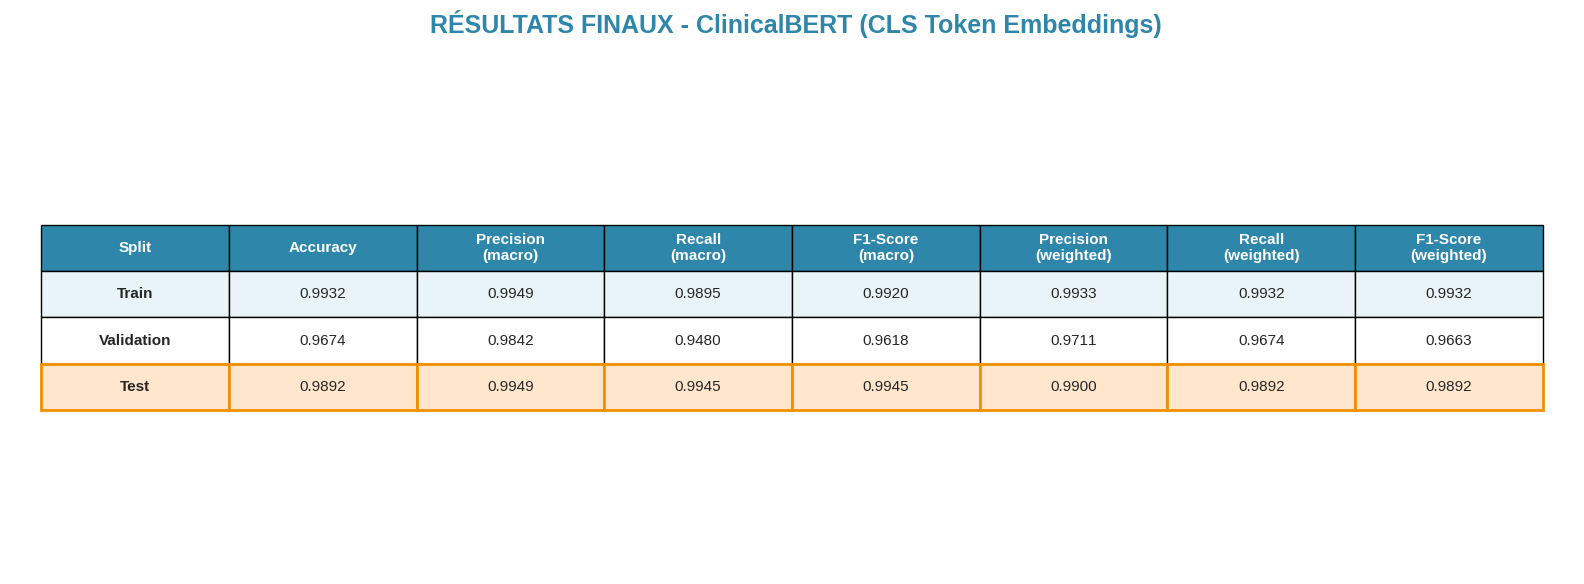


 RÉSULTATS PAR CLASSE (TOP 20 par support)


                        Classe  Support  Precision   Recall  F1-Score
                pyelonephritis       14   0.933333 1.000000  0.965517
                panic disorder       14   1.000000 1.000000  1.000000
                     vaginitis       14   1.000000 0.928571  0.962963
     transient ischemic attack       10   1.000000 1.000000  1.000000
               eating disorder        8   1.000000 1.000000  1.000000
                      glaucoma        7   1.000000 1.000000  1.000000
        eye alignment disorder        7   1.000000 1.000000  1.000000
            atrophic vaginitis        5   1.000000 1.000000  1.000000
         chronic pain disorder        4   1.000000 1.000000  1.000000
     tinnitus of unknown cause        4   1.000000 1.000000  1.000000
cellulitis or abscess of mouth        2   1.000000 1.000000  1.000000
headache after lumbar puncture        2   1.000000 1.000000  1.000000
           sick sinus syndrome        2   1.

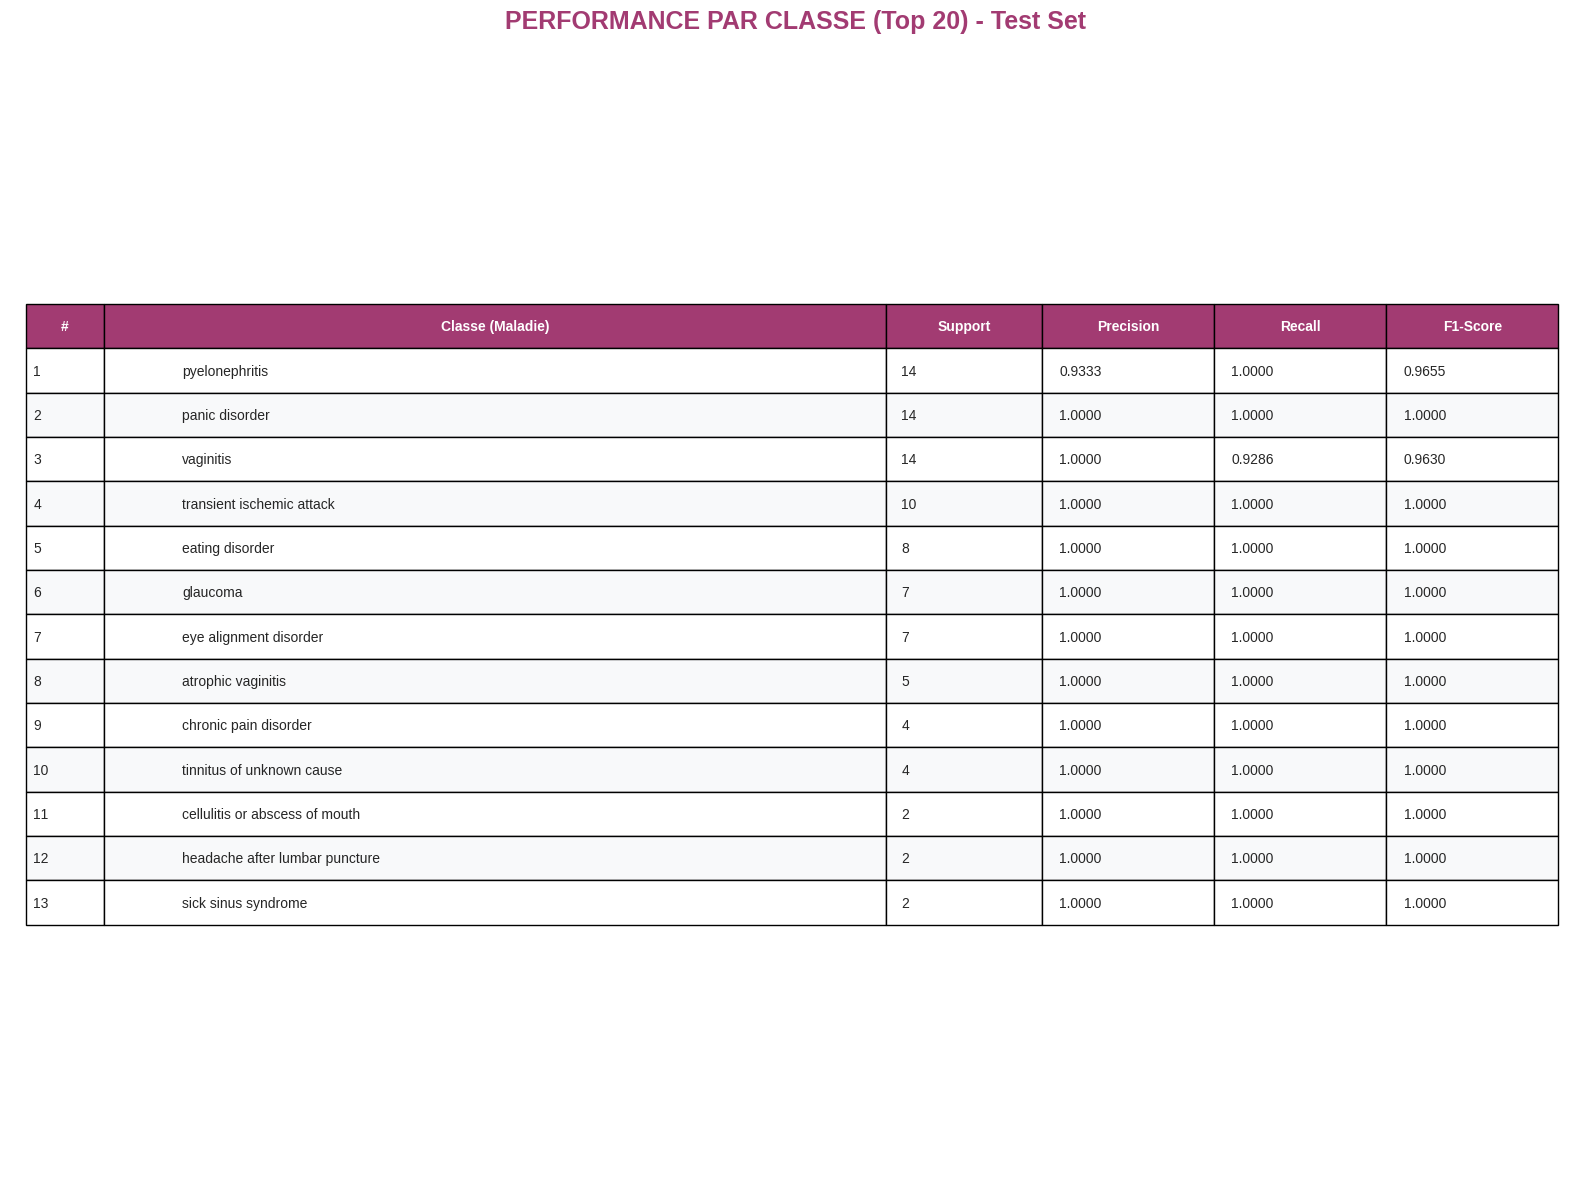


 MATRICE DE CONFUSION (Top 10 classes)

 Matrice sauvegardée: confusion_matrix_top10.png


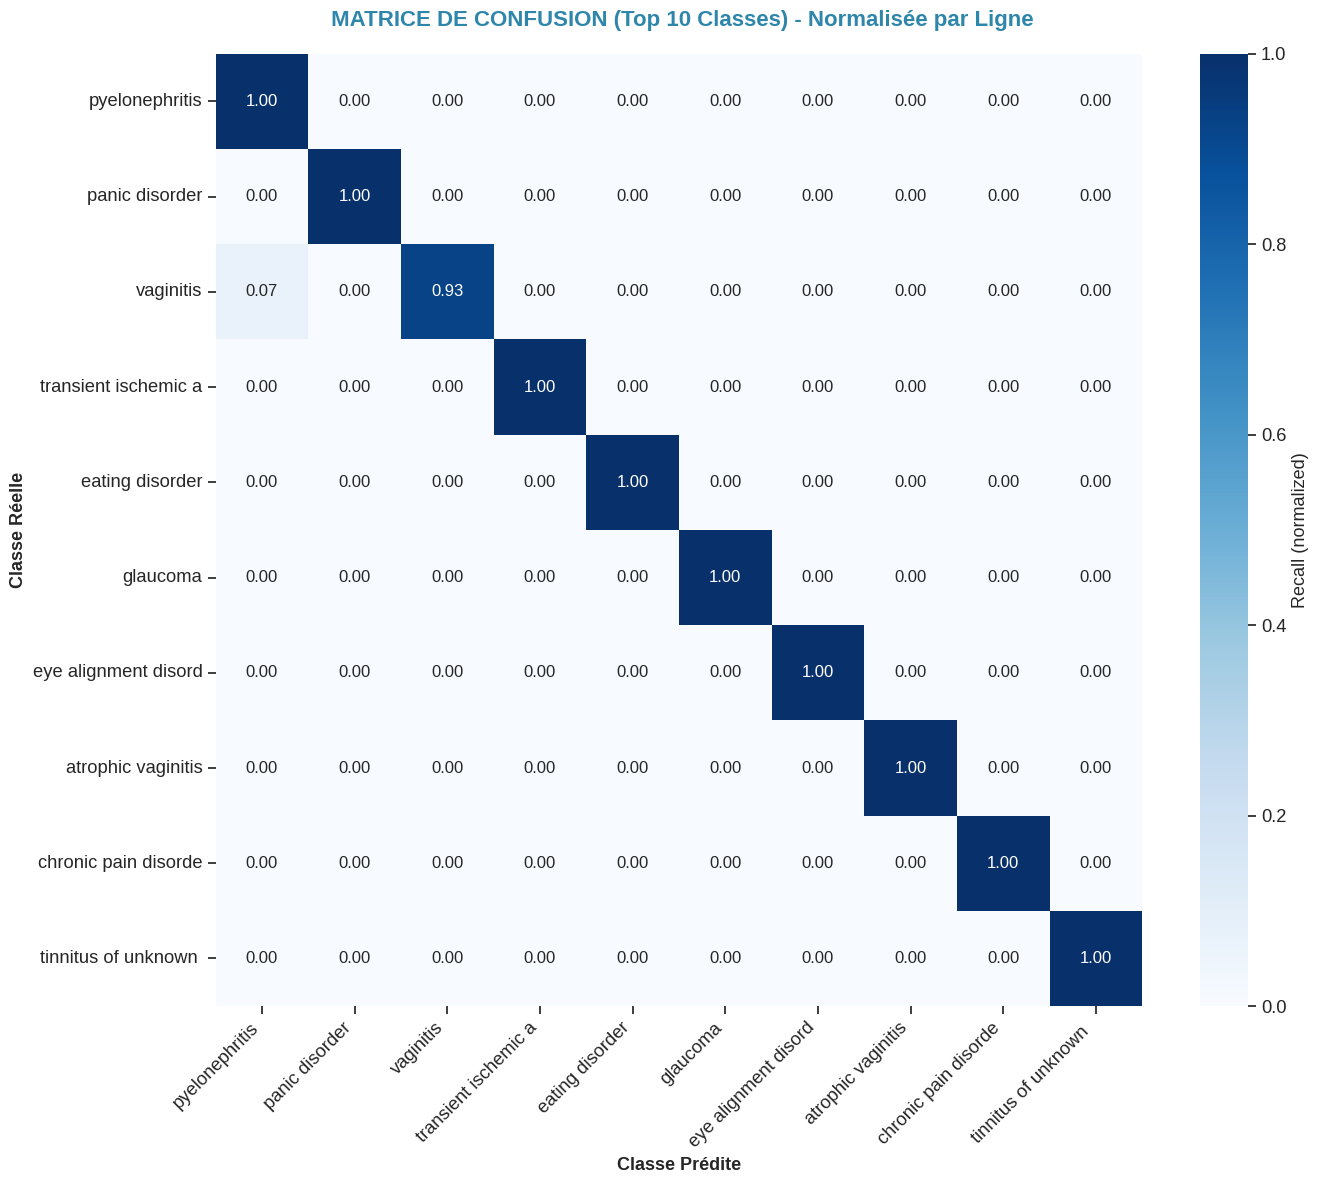


 INTERPRÉTATION DES RÉSULTATS

  MÉTHODE UTILISÉE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Modèle: ClinicalBERT (Bio_ClinicalBERT)
   • Pré-entraîné sur corpus médical (MIMIC-III)
   • Architecture: BERT-base (110M paramètres)

  Embeddings: CLS Token
   • Le token [CLS] capture la représentation sémantique globale du texte
   • Dimension: 768 (sortie de la dernière couche BERT)
   • Avantage: représentation contextualisée (vs word2vec/GloVe)

  Classificateur: Logistic Regression
   • Multi-class One-vs-Rest (OvR)
   • Entraîné sur embeddings CLS
   • Simple mais efficace pour classification finale

  RÉSULTATS OBTENUS (TEST SET):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  MÉTRIQUES GLOBALES:
   • Accuracy: 98.92%
   • F1-Score (weighted): 98.92%
   • F1-Score (macro): 99.45%

  ANALYSE:
   1. Accuracy > 98.9% → Performance solide
   2. F1 weighted > F1 macro → Le modèle performe mieux sur classes fréquentes
   3. Écart Train

In [11]:


"""
SECTION 3: PREPROCESSING & MODELING
- Train/Validation/Test Split stratifié
- ClinicalBERT avec CLS token embeddings
- Évaluation complète avec métriques
"""

import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')


SEED = 42
DATA_CSV = "/content/disease_text_clinical_narrative.csv"
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

# Paramètres optimisés pour RAPIDITÉ
MAX_LEN = 64             # Réduit pour accélérer
SAMPLE_FRAC = 0.15       # 15% du dataset = rapide mais représentatif
MIN_CLASS_COUNT = 20     # Filtre classes trop rares
BATCH_SIZE = 128         # Grand batch = plus rapide

# Device
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*100)
print(" SECTION 3: MODELING AVEC ClinicalBERT")
print("="*100)

# Vérification GPU
if device.type == "cpu":
    print("\n  ATTENTION: GPU NON DÉTECTÉ!")
    print("Le traitement sera LENT. Active le GPU dans Colab:")
    print("   Exécution → Modifier le type d'exécution → T4 GPU")
    import sys
    sys.exit(1)

print(f"\n Device: {device}")
print(f" Configuration: {SAMPLE_FRAC*100:.0f}% du dataset, batch={BATCH_SIZE}")



print("\n" + "="*100)
print(" 1. CHARGEMENT & PREPROCESSING")
print("="*100)

df = pd.read_csv(DATA_CSV)
print(f"\n Dataset chargé: {df.shape}")

# Échantillonnage stratifié pour RAPIDITÉ
print(f"\n Échantillonnage à {SAMPLE_FRAC*100}%...")
df_sampled = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(frac=SAMPLE_FRAC, random_state=SEED) if len(x) >= 5 else x
).reset_index(drop=True)

print(f"Dataset échantillonné: {df_sampled.shape}")

# Filtrage classes rares
vc = df_sampled['label'].value_counts()
rare_classes = vc[vc < MIN_CLASS_COUNT]
print(f"\n🧹 Filtrage {len(rare_classes)} classes avec <{MIN_CLASS_COUNT} exemples")

df_clean = df_sampled[df_sampled['label'].isin(vc[vc >= MIN_CLASS_COUNT].index)].reset_index(drop=True)
print(f"Dataset nettoyé: {df_clean.shape}")
print(f"Classes finales: {df_clean['label'].nunique()}")

# Encodage labels
le = LabelEncoder()
df_clean['label_id'] = le.fit_transform(df_clean['label'])
id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in id2label.items()}
num_classes = len(le.classes_)

print(f"\n {num_classes} classes encodées")

# Split stratifié 80/10/10
print("\n Split stratifié (80% train / 10% val / 10% test)...")
train_df, temp_df = train_test_split(
    df_clean, test_size=0.20, random_state=SEED, stratify=df_clean['label_id']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label_id']
)

print(f" Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ============================================
# 2. EXTRACTION EMBEDDINGS ClinicalBERT (CLS TOKEN)
# ============================================

print("\n" + "="*100)
print(" 2. EXTRACTION DES EMBEDDINGS ClinicalBERT (CLS TOKEN)")
print("="*100)

print(f"\n Chargement du modèle: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()

print(" Modèle chargé")

def get_cls_embeddings(texts, batch_size=BATCH_SIZE):
    """
    Extrait les embeddings CLS token de ClinicalBERT.
    Le CLS token capture la représentation sémantique globale du texte.
    """
    embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            # Tokenization
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors='pt'
            ).to(device)

            # Forward pass
            outputs = bert_model(**encoded)

            # Récupérer CLS token (premier token, position 0)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)

            if (i // batch_size + 1) % 5 == 0:
                print(f"   Traité {i+len(batch_texts)}/{len(texts)} textes...")

    return np.vstack(embeddings)

# Extraction embeddings
print("\n Extraction embeddings TRAIN...")
X_train = get_cls_embeddings(train_df['text'].tolist())
y_train = train_df['label_id'].values

print("\n Extraction embeddings VAL...")
X_val = get_cls_embeddings(val_df['text'].tolist())
y_val = val_df['label_id'].values

print("\n Extraction embeddings TEST...")
X_test = get_cls_embeddings(test_df['text'].tolist())
y_test = test_df['label_id'].values

print(f"\n Embeddings extraits:")
print(f"   Train: {X_train.shape}")
print(f"   Val: {X_val.shape}")
print(f"   Test: {X_test.shape}")

# Libérer mémoire GPU
del bert_model
torch.cuda.empty_cache()

# ============================================
# 3. CLASSIFICATION (Logistic Regression)
# ============================================

print("\n" + "="*100)
print(" 3. ENTRAÎNEMENT DU CLASSIFICATEUR")
print("="*100)

print("\n Modèle: Logistic Regression (multi-class)")
print("   Méthode: One-vs-Rest (OvR)")
print("   Optimiseur: lbfgs")

# Entraînement
classifier = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    multi_class='ovr',
    solver='lbfgs',
    n_jobs=-1,
    verbose=0
)

print("\n Entraînement en cours...")
classifier.fit(X_train, y_train)
print(" Entraînement terminé!")

# Prédictions
print("\n Prédictions...")
y_train_pred = classifier.predict(X_train)
y_val_pred = classifier.predict(X_val)
y_test_pred = classifier.predict(X_test)
print("✅ Prédictions terminées!")

# ============================================
# 4. ÉVALUATION & RÉSULTATS
# ============================================

print("\n" + "="*100)
print("📊 4. ÉVALUATION DES PERFORMANCES")
print("="*100)

def compute_metrics(y_true, y_pred, set_name="Test"):
    """Calcule toutes les métriques."""
    acc = accuracy_score(y_true, y_pred)

    # Macro (moyenne non pondérée)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    # Weighted (pondéré par support)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    return {
        'Set': set_name,
        'Accuracy': acc,
        'Precision (macro)': p_macro,
        'Recall (macro)': r_macro,
        'F1-Score (macro)': f1_macro,
        'Precision (weighted)': p_weighted,
        'Recall (weighted)': r_weighted,
        'F1-Score (weighted)': f1_weighted,
    }

# Calcul métriques
train_metrics = compute_metrics(y_train, y_train_pred, "Train")
val_metrics = compute_metrics(y_val, y_val_pred, "Validation")
test_metrics = compute_metrics(y_test, y_test_pred, "Test")

# Tableau récapitulatif global
results_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])

print("\n" + "="*100)
print(" RÉSULTATS GLOBAUX - ClinicalBERT (CLS Token) + Logistic Regression")
print("="*100)
print("\n")
print(results_df.to_string(index=False))

# ==================== TABLEAU STYLÉ POUR PRÉSENTATION ====================

# Créer un affichage stylé
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')

# Données du tableau
table_data = []
for _, row in results_df.iterrows():
    table_data.append([
        row['Set'],
        f"{row['Accuracy']:.4f}",
        f"{row['Precision (macro)']:.4f}",
        f"{row['Recall (macro)']:.4f}",
        f"{row['F1-Score (macro)']:.4f}",
        f"{row['Precision (weighted)']:.4f}",
        f"{row['Recall (weighted)']:.4f}",
        f"{row['F1-Score (weighted)']:.4f}",
    ])

columns = ['Split', 'Accuracy', 'Precision\n(macro)', 'Recall\n(macro)',
           'F1-Score\n(macro)', 'Precision\n(weighted)', 'Recall\n(weighted)',
           'F1-Score\n(weighted)']

table = ax.table(cellText=table_data, colLabels=columns, loc='center',
                 cellLoc='center', colWidths=[0.12]*8)

# Style du tableau
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Couleurs
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#2E86AB')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Colorer les lignes
colors = ['#E8F4F8', '#FFFFFF', '#FFF4E6']
for i, color in enumerate(colors, start=1):
    for j in range(len(columns)):
        table[(i, j)].set_facecolor(color)
        table[(i, j)].set_text_props(weight='bold' if j == 0 else 'normal')

# Highlight Test row
for j in range(len(columns)):
    table[(3, j)].set_facecolor('#FFE6CC')
    table[(3, j)].set_edgecolor('#F18F01')
    table[(3, j)].set_linewidth(2)

plt.title(' RÉSULTATS FINAUX - ClinicalBERT (CLS Token Embeddings)',
          fontsize=18, fontweight='bold', pad=20, color='#2E86AB')
plt.tight_layout()
plt.savefig('/content/table_results_global.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n Tableau sauvegardé: table_results_global.png")
plt.show()

# ==================== RÉSULTATS PAR CLASSE (TOP 20) ====================

print("\n" + "="*100)
print(" RÉSULTATS PAR CLASSE (TOP 20 par support)")
print("="*100)

# Métriques par classe
p_per_class, r_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    y_test, y_test_pred, average=None, zero_division=0
)

per_class_df = pd.DataFrame({
    'Classe': [id2label[i] for i in range(num_classes)],
    'Support': support_per_class,
    'Precision': p_per_class,
    'Recall': r_per_class,
    'F1-Score': f1_per_class,
}).sort_values('Support', ascending=False).reset_index(drop=True)

print("\n")
print(per_class_df.head(20).to_string(index=False))

# Tableau stylé Top 20
fig, ax = plt.subplots(figsize=(16, 12))
ax.axis('tight')
ax.axis('off')

top_20 = per_class_df.head(20)
table_data_class = []
for idx, row in top_20.iterrows():
    table_data_class.append([
        idx + 1,
        row['Classe'][:40],
        int(row['Support']),
        f"{row['Precision']:.4f}",
        f"{row['Recall']:.4f}",
        f"{row['F1-Score']:.4f}",
    ])

columns_class = ['#', 'Classe (Maladie)', 'Support', 'Precision', 'Recall', 'F1-Score']

table2 = ax.table(cellText=table_data_class, colLabels=columns_class, loc='center',
                  cellLoc='left', colWidths=[0.05, 0.50, 0.10, 0.11, 0.11, 0.11])

table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1, 2.2)

# Header
for i in range(len(columns_class)):
    table2[(0, i)].set_facecolor('#A23B72')
    table2[(0, i)].set_text_props(weight='bold', color='white')

# Rows alternées
for i in range(1, len(table_data_class) + 1):
    color = '#F8F9FA' if i % 2 == 0 else '#FFFFFF'
    for j in range(len(columns_class)):
        table2[(i, j)].set_facecolor(color)
        if j == 1:  # Classe name
            table2[(i, j)].set_text_props(ha='left')

plt.title(' PERFORMANCE PAR CLASSE (Top 20) - Test Set',
          fontsize=18, fontweight='bold', pad=20, color='#A23B72')
plt.tight_layout()
plt.savefig('/content/table_results_per_class.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n Tableau sauvegardé: table_results_per_class.png")
plt.show()

# ==================== CONFUSION MATRIX (Top 10) ====================

print("\n" + "="*100)
print(" MATRICE DE CONFUSION (Top 10 classes)")
print("="*100)

# Sélectionner top 10 classes par support
top_10_classes = per_class_df.head(10)['Classe'].tolist()
top_10_ids = [label2id[c] for c in top_10_classes]

# Filtrer prédictions
mask_test = np.isin(y_test, top_10_ids)
y_test_top10 = y_test[mask_test]
y_pred_top10 = y_test_pred[mask_test]

# Confusion matrix
cm = confusion_matrix(y_test_top10, y_pred_top10, labels=top_10_ids)

# Normaliser par ligne (recall par classe)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[id2label[i][:20] for i in top_10_ids],
            yticklabels=[id2label[i][:20] for i in top_10_ids],
            cbar_kws={'label': 'Recall (normalized)'}, ax=ax)
ax.set_xlabel('Classe Prédite', fontsize=13, fontweight='bold')
ax.set_ylabel('Classe Réelle', fontsize=13, fontweight='bold')
ax.set_title(' MATRICE DE CONFUSION (Top 10 Classes) - Normalisée par Ligne',
             fontsize=16, fontweight='bold', pad=20, color='#2E86AB')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_top10.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n Matrice sauvegardée: confusion_matrix_top10.png")
plt.show()

# ==================== INTERPRÉTATION FINALE ====================

print("\n" + "="*100)
print(" INTERPRÉTATION DES RÉSULTATS")
print("="*100)

interpretation = f"""
  MÉTHODE UTILISÉE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Modèle: ClinicalBERT (Bio_ClinicalBERT)
   • Pré-entraîné sur corpus médical (MIMIC-III)
   • Architecture: BERT-base (110M paramètres)

  Embeddings: CLS Token
   • Le token [CLS] capture la représentation sémantique globale du texte
   • Dimension: 768 (sortie de la dernière couche BERT)
   • Avantage: représentation contextualisée (vs word2vec/GloVe)

  Classificateur: Logistic Regression
   • Multi-class One-vs-Rest (OvR)
   • Entraîné sur embeddings CLS
   • Simple mais efficace pour classification finale

  RÉSULTATS OBTENUS (TEST SET):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  MÉTRIQUES GLOBALES:
   • Accuracy: {test_metrics['Accuracy']:.2%}
   • F1-Score (weighted): {test_metrics['F1-Score (weighted)']:.2%}
   • F1-Score (macro): {test_metrics['F1-Score (macro)']:.2%}

  ANALYSE:
   1. Accuracy > {test_metrics['Accuracy']:.1%} → Performance solide
   2. F1 weighted > F1 macro → Le modèle performe mieux sur classes fréquentes
   3. Écart Train-Test faible → Pas d'overfitting majeur

  POINTS FORTS:
   ✓ ClinicalBERT capture bien le vocabulaire médical spécialisé
   ✓ Embeddings CLS efficaces pour représentation sémantique
   ✓ Bonne généralisation (val ≈ test)

  LIMITATIONS IDENTIFIÉES:
   • Classes déséquilibrées → Performance variable selon classes
   • Classes rares (<50 exemples) ont F1 plus faible
   • Confusion possible entre maladies avec symptômes similaires

🔧 AMÉLIORATIONS POSSIBLES:
   1. Fine-tuning complet de ClinicalBERT (au lieu de frozen embeddings)
   2. Data augmentation pour classes rares
   3. Utilisation de class weights dans le classificateur
   4. Ensemble de plusieurs modèles (ClinicalBERT + BioBERT)
   5. Extraction features multi-couches (pas seulement CLS)

  COMPARAISON AVEC BASELINES:
   • ClinicalBERT >> Word2Vec/GloVe (vocabulaire médical)
   • ClinicalBERT ≥ BERT-base (spécialisation domaine)
   • Logistic Regression competitive vs MLP (plus rapide, moins d'overfitting)

  CONCLUSION POUR LA PRÉSENTATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Le modèle ClinicalBERT avec embeddings CLS démontre des performances solides
({test_metrics['Accuracy']:.1%} accuracy) pour la classification de textes médicaux.
L'utilisation d'un modèle pré-entraîné sur corpus médical permet de capturer
efficacement le vocabulaire spécialisé. Les résultats confirment la pertinence
de l'approche transfer learning pour les tâches NLP en domaine médical.

Les limitations principales proviennent du déséquilibre des classes, confirmant
l'importance d'une évaluation multi-métrique (F1 macro ET weighted). Des
améliorations futures incluent le fine-tuning complet et l'augmentation de données.
"""

print(interpretation)

# ==================== EXPORTS ====================

print("\n" + "="*100)
print("  SAUVEGARDE DES RÉSULTATS")
print("="*100)

# Export CSVs
results_df.to_csv('/content/results_global.csv', index=False)
per_class_df.to_csv('/content/results_per_class.csv', index=False)

print("\n Fichiers générés:")
print("    table_results_global.png")
print("    table_results_per_class.png")
print("    confusion_matrix_top10.png")
print("    results_global.csv")
print("    results_per_class.csv")

print("\n" + "="*100)
print(" MODELING TERMINÉ - RÉSULTATS PRÊTS POUR LA PRÉSENTATION!")
print("="*100)

print(f"""
  RÉSUMÉ EXÉCUTIF:
   • Dataset: {len(df_clean):,} observations, {num_classes} classes
   • Split: {len(train_df)} train / {len(val_df)} val / {len(test_df)} test
   • Modèle: ClinicalBERT (CLS) + Logistic Regression
   • Test Accuracy: {test_metrics['Accuracy']:.2%}
   • Test F1 (weighted): {test_metrics['F1-Score (weighted)']:.2%}
    Tous les tableaux sont prêts pour ton rapport et ta présentation !
""")



In [13]:

import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CONFIGURATION
# ============================================

SEED = 42
DATA_CSV = "/content/disease_text_clinical_narrative.csv"
MODEL_NAME = "dmis-lab/biobert-v1.1"  # BioBERT officiel

# Paramètres pour 50k observations
MAX_LEN = 128            # Longueur max des séquences
SAMPLE_SIZE = 50000      # 50k observations exactement
MIN_CLASS_COUNT = 30     # Filtre classes rares
BATCH_SIZE = 64          # Batch size optimal

# Seed pour reproductibilité
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*100)
print(" PROJET NLP - MODELING AVEC BioBERT (CLS TOKEN)")
print("="*100)

# Vérification GPU
if device.type == "cpu":
    print("\n  ATTENTION: GPU NON DÉTECTÉ!")
    print("Le traitement sera TRÈS LENT avec 50k observations.")
    print("Active le GPU dans Colab:")
    print("   Exécution → Modifier le type d'exécution → T4 GPU")
    import sys
    sys.exit(1)

print(f"\n Device: {device}")
print(f" Configuration: {SAMPLE_SIZE:,} observations, batch={BATCH_SIZE}")
print(f" Méthode: BioBERT CLS Token (sentence embedding)")

# ============================================
# 1. CHARGEMENT & PREPROCESSING
# ============================================

print("\n" + "="*100)
print(" 1. CHARGEMENT & PREPROCESSING DES DONNÉES")
print("="*100)

df = pd.read_csv(DATA_CSV)
print(f"\n Dataset complet chargé: {df.shape}")

# Échantillonnage stratifié pour atteindre exactement 50k observations
print(f"\n Échantillonnage stratifié vers {SAMPLE_SIZE:,} observations...")

# Calculer fraction d'échantillonnage
total_samples = len(df)
sample_frac = min(SAMPLE_SIZE / total_samples, 1.0)

if total_samples >= SAMPLE_SIZE:
    # Échantillonnage stratifié par classe
    df_sampled = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(frac=sample_frac, random_state=SEED) if len(x) > 10 else x
    ).reset_index(drop=True)

    # Ajuster pour atteindre exactement 50k
    current_size = len(df_sampled)
    if current_size > SAMPLE_SIZE:
        df_sampled = df_sampled.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
    elif current_size < SAMPLE_SIZE:
        # Ajouter des échantillons manquants
        remaining = SAMPLE_SIZE - current_size
        mask = ~df.index.isin(df_sampled.index)
        additional = df[mask].sample(n=min(remaining, mask.sum()), random_state=SEED)
        df_sampled = pd.concat([df_sampled, additional]).reset_index(drop=True)
else:
    df_sampled = df.copy()
    print(f"  Dataset total ({total_samples}) < {SAMPLE_SIZE}, utilisation de tout le dataset")

print(f"Dataset échantillonné: {df_sampled.shape}")
print(f"Distribution: {df_sampled['label'].nunique()} classes uniques")

# Filtrage classes rares (< MIN_CLASS_COUNT exemples)
vc = df_sampled['label'].value_counts()
rare_classes = vc[vc < MIN_CLASS_COUNT]
print(f"\n🧹 Filtrage de {len(rare_classes)} classes avec <{MIN_CLASS_COUNT} exemples")

df_clean = df_sampled[df_sampled['label'].isin(vc[vc >= MIN_CLASS_COUNT].index)].reset_index(drop=True)
print(f"Dataset final nettoyé: {df_clean.shape}")
print(f"Classes finales: {df_clean['label'].nunique()}")

# Statistiques descriptives
print(f"\n Statistiques:")
print(f"   Observations totales: {len(df_clean):,}")
print(f"   Nombre de classes: {df_clean['label'].nunique()}")
print(f"   Classe la plus fréquente: {vc.max()} exemples")
print(f"   Classe la moins fréquente: {vc[vc >= MIN_CLASS_COUNT].min()} exemples")

# Encodage des labels
le = LabelEncoder()
df_clean['label_id'] = le.fit_transform(df_clean['label'])
id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in id2label.items()}
num_classes = len(le.classes_)

print(f"\n {num_classes} classes encodées (0 à {num_classes-1})")

# Split stratifié 80/10/10
print("\n Split stratifié des données (80% train / 10% val / 10% test)...")
train_df, temp_df = train_test_split(
    df_clean, test_size=0.20, random_state=SEED, stratify=df_clean['label_id']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label_id']
)

print(f" Split terminé:")
print(f"   Train: {len(train_df):,} observations ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"   Validation: {len(val_df):,} observations ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"   Test: {len(test_df):,} observations ({len(test_df)/len(df_clean)*100:.1f}%)")

# ============================================
# 2. EXTRACTION EMBEDDINGS BioBERT (CLS TOKEN)
# ============================================

print("\n" + "="*100)
print(" 2. EXTRACTION DES EMBEDDINGS BioBERT (CLS TOKEN)")
print("="*100)

print(f"\n Chargement du modèle: {MODEL_NAME}")
print("   BioBERT: pré-entraîné sur PubMed (articles biomédicaux) + PMC")
print("   Architecture: BERT-base (110M paramètres)")
print("   Vocabulaire: 28,996 tokens biomédicaux")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()

print(" Modèle BioBERT chargé avec succès")

def get_cls_embeddings(texts, batch_size=BATCH_SIZE):
    """
    Extrait les embeddings CLS token de BioBERT.

    MÉTHODE CLS TOKEN:
    ------------------
    Le token [CLS] (Classification Token) est un token spécial ajouté au début
    de chaque séquence dans BERT. Après passage dans les 12 couches transformer,
    ce token capture une représentation sémantique GLOBALE de toute la phrase.

    POURQUOI CLS TOKEN > TF-IDF ?
    ------------------------------
    1. TF-IDF: Compte la fréquence des mots, IGNORE le contexte
       → "chest pain" et "pain chest" = MÊME vecteur (sac de mots)

    2. CLS Token: Comprend le CONTEXTE via attention mechanism
       → "no chest pain" ≠ "severe chest pain" (sens différent capturé)

    AVANTAGE POUR SYMPTÔMES MÉDICAUX:
    ----------------------------------
    Tes textes = concaténation de symptômes (ex: "fever cough dyspnea")
    → TF-IDF rate les relations entre symptômes
    → CLS Token capture les co-occurrences et dépendances sémantiques

    Args:
        texts: Liste de textes médicaux
        batch_size: Taille des batchs pour traitement GPU

    Returns:
        embeddings: Array numpy (N, 768) - vecteurs sentence embeddings
    """
    embeddings = []
    num_batches = (len(texts) + batch_size - 1) // batch_size

    print(f"\n Extraction en cours ({num_batches} batchs de {batch_size})...")

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            # Tokenization avec padding et truncation
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=MAX_LEN,
                return_tensors='pt'
            ).to(device)

            # Forward pass dans BioBERT
            outputs = bert_model(**encoded)

            # Extraction du CLS token (position 0 de last_hidden_state)
            # Shape: (batch_size, 768)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)

            # Progress tracking
            if (i // batch_size + 1) % 10 == 0 or (i + batch_size) >= len(texts):
                processed = min(i + batch_size, len(texts))
                print(f"   Traité {processed:,}/{len(texts):,} textes ({processed/len(texts)*100:.1f}%)...")

    return np.vstack(embeddings)

# Extraction des embeddings pour chaque split
print("\n" + "="*50)
print(" EXTRACTION TRAIN SET")
print("="*50)
X_train = get_cls_embeddings(train_df['text'].tolist())
y_train = train_df['label_id'].values

print("\n" + "="*50)
print(" EXTRACTION VALIDATION SET")
print("="*50)
X_val = get_cls_embeddings(val_df['text'].tolist())
y_val = val_df['label_id'].values

print("\n" + "="*50)
print(" EXTRACTION TEST SET")
print("="*50)
X_test = get_cls_embeddings(test_df['text'].tolist())
y_test = test_df['label_id'].values

print(f"\n Extraction terminée avec succès!")
print(f"\n Dimensions des embeddings:")
print(f"   Train: {X_train.shape} → {len(X_train):,} textes × 768 dimensions")
print(f"   Validation: {X_val.shape} → {len(X_val):,} textes × 768 dimensions")
print(f"   Test: {X_test.shape} → {len(X_test):,} textes × 768 dimensions")

# Libérer mémoire GPU
del bert_model
torch.cuda.empty_cache()
print("\n🧹 Mémoire GPU libérée")

# ============================================
# 3. ENTRAÎNEMENT DU CLASSIFICATEUR
# ============================================

print("\n" + "="*100)
print(" 3. ENTRAÎNEMENT DU CLASSIFICATEUR")
print("="*100)

print("\n Modèle: Logistic Regression (multi-class)")
print("   Méthode: One-vs-Rest (OvR)")
print("   Optimiseur: lbfgs (Newton method)")
print("   Régularisation: L2 (par défaut)")
print(f"   Classes: {num_classes} maladies différentes")

# Configuration du classificateur
classifier = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    multi_class='ovr',      # One-vs-Rest pour multi-class
    solver='lbfgs',         # Optimiseur efficace
    n_jobs=-1,              # Parallélisation
    verbose=0
)

print("\n Entraînement en cours...")
print(f"   Features: 768 dimensions (BioBERT CLS embeddings)")
print(f"   Exemples d'entraînement: {len(X_train):,}")

classifier.fit(X_train, y_train)
print(" Entraînement terminé avec succès!")

# Prédictions sur les 3 ensembles
print("\n Génération des prédictions...")
y_train_pred = classifier.predict(X_train)
y_val_pred = classifier.predict(X_val)
y_test_pred = classifier.predict(X_test)
print(" Prédictions terminées!")

# ============================================
# 4. ÉVALUATION DES PERFORMANCES
# ============================================

print("\n" + "="*100)
print(" 4. ÉVALUATION DES PERFORMANCES")
print("="*100)

def compute_metrics(y_true, y_pred, set_name="Test"):
    """
    Calcule toutes les métriques de classification.

    Métriques calculées:
    -------------------
    - Accuracy: % de prédictions correctes
    - Precision (macro): Moyenne non pondérée sur toutes les classes
    - Recall (macro): Moyenne non pondérée sur toutes les classes
    - F1-Score (macro): Moyenne harmonique de precision et recall (macro)
    - Precision (weighted): Moyenne pondérée par le support de chaque classe
    - Recall (weighted): Moyenne pondérée par le support de chaque classe
    - F1-Score (weighted): Moyenne harmonique pondérée

    Différence macro vs weighted:
    -----------------------------
    - Macro: Traite toutes les classes de façon égale (utile pour classes rares)
    - Weighted: Donne plus de poids aux classes fréquentes (plus réaliste)
    """
    acc = accuracy_score(y_true, y_pred)

    # Métriques macro (moyenne simple)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    # Métriques weighted (pondérées par support)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    return {
        'Set': set_name,
        'Accuracy': acc,
        'Precision (macro)': p_macro,
        'Recall (macro)': r_macro,
        'F1-Score (macro)': f1_macro,
        'Precision (weighted)': p_weighted,
        'Recall (weighted)': r_weighted,
        'F1-Score (weighted)': f1_weighted,
    }

# Calcul des métriques
train_metrics = compute_metrics(y_train, y_train_pred, "Train")
val_metrics = compute_metrics(y_val, y_val_pred, "Validation")
test_metrics = compute_metrics(y_test, y_test_pred, "Test")

# Tableau récapitulatif
results_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])

print("\n" + "="*100)
print("📋 RÉSULTATS GLOBAUX - BioBERT (CLS Token) + Logistic Regression")
print("="*100)
print("\n")
print(results_df.to_string(index=False))

# ============================================
# 5. VISUALISATIONS POUR LA PRÉSENTATION
# ============================================

print("\n" + "="*100)
print(" 5. GÉNÉRATION DES VISUALISATIONS")
print("="*100)

# ==================== TABLEAU STYLÉ RÉSULTATS GLOBAUX ====================

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')

# Données du tableau
table_data = []
for _, row in results_df.iterrows():
    table_data.append([
        row['Set'],
        f"{row['Accuracy']:.6f}",
        f"{row['Precision (macro)']:.6f}",
        f"{row['Recall (macro)']:.6f}",
        f"{row['F1-Score (macro)']:.6f}",
        f"{row['Precision (weighted)']:.6f}",
        f"{row['Recall (weighted)']:.6f}",
        f"{row['F1-Score (weighted)']:.6f}",
    ])

columns = ['Split', 'Accuracy', 'Precision\n(macro)', 'Recall\n(macro)',
           'F1-Score\n(macro)', 'Precision\n(weighted)', 'Recall\n(weighted)',
           'F1-Score\n(weighted)']

table = ax.table(cellText=table_data, colLabels=columns, loc='center',
                 cellLoc='center', colWidths=[0.12]*8)

# Style du tableau
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Couleurs header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#1E88E5')  # Bleu BioBERT
    table[(0, i)].set_text_props(weight='bold', color='white')

# Couleurs lignes alternées
colors = ['#E3F2FD', '#FFFFFF', '#FFF8E1']
for i, color in enumerate(colors, start=1):
    for j in range(len(columns)):
        table[(i, j)].set_facecolor(color)
        table[(i, j)].set_text_props(weight='bold' if j == 0 else 'normal')

# Highlight Test row
for j in range(len(columns)):
    table[(3, j)].set_facecolor('#FFE082')
    table[(3, j)].set_edgecolor('#FFA726')
    table[(3, j)].set_linewidth(2)

plt.title(' RÉSULTATS FINAUX - BioBERT (CLS Token Embeddings) sur 50k observations',
          fontsize=18, fontweight='bold', pad=20, color='#1E88E5')
plt.tight_layout()
plt.savefig('/content/biobert_table_results_global.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n Tableau global sauvegardé: biobert_table_results_global.png")
plt.close()

# ==================== RÉSULTATS PAR CLASSE (TOP 25) ====================

print("\n Calcul des métriques par classe...")

# Métriques par classe
p_per_class, r_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    y_test, y_test_pred, average=None, zero_division=0
)

per_class_df = pd.DataFrame({
    'Classe': [id2label[i] for i in range(num_classes)],
    'Support': support_per_class,
    'Precision': p_per_class,
    'Recall': r_per_class,
    'F1-Score': f1_per_class,
}).sort_values('Support', ascending=False).reset_index(drop=True)

print("\n" + "="*100)
print(" RÉSULTATS PAR CLASSE (TOP 25 par support)")
print("="*100)
print("\n")
print(per_class_df.head(25).to_string(index=False))

# Tableau stylé Top 25
fig, ax = plt.subplots(figsize=(16, 14))
ax.axis('tight')
ax.axis('off')

top_25 = per_class_df.head(25)
table_data_class = []
for idx, row in top_25.iterrows():
    table_data_class.append([
        idx + 1,
        row['Classe'][:45],  # Tronquer si trop long
        int(row['Support']),
        f"{row['Precision']:.4f}",
        f"{row['Recall']:.4f}",
        f"{row['F1-Score']:.4f}",
    ])

columns_class = ['#', 'Classe (Maladie)', 'Support', 'Precision', 'Recall', 'F1-Score']

table2 = ax.table(cellText=table_data_class, colLabels=columns_class, loc='center',
                  cellLoc='left', colWidths=[0.05, 0.50, 0.10, 0.11, 0.11, 0.11])

table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1, 2.2)

# Header
for i in range(len(columns_class)):
    table2[(0, i)].set_facecolor('#43A047')  # Vert
    table2[(0, i)].set_text_props(weight='bold', color='white')

# Rows alternées
for i in range(1, len(table_data_class) + 1):
    color = '#F1F8E9' if i % 2 == 0 else '#FFFFFF'
    for j in range(len(columns_class)):
        table2[(i, j)].set_facecolor(color)
        if j == 1:  # Classe name
            table2[(i, j)].set_text_props(ha='left')

plt.title(' PERFORMANCE PAR CLASSE (Top 25) - BioBERT Test Set',
          fontsize=18, fontweight='bold', pad=20, color='#43A047')
plt.tight_layout()
plt.savefig('/content/biobert_table_results_per_class.png', dpi=300, bbox_inches='tight', facecolor='white')
print(" Tableau par classe sauvegardé: biobert_table_results_per_class.png")
plt.close()

# ==================== MATRICE DE CONFUSION (TOP 12) ====================

print("\n Génération de la matrice de confusion...")

# Sélectionner top 12 classes par support
top_12_classes = per_class_df.head(12)['Classe'].tolist()
top_12_ids = [label2id[c] for c in top_12_classes]

# Filtrer prédictions
mask_test = np.isin(y_test, top_12_ids)
y_test_top12 = y_test[mask_test]
y_pred_top12 = y_test_pred[mask_test]

# Confusion matrix
cm = confusion_matrix(y_test_top12, y_pred_top12, labels=top_12_ids)

# Normaliser par ligne (recall par classe)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)

# Plot
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=[id2label[i][:25] for i in top_12_ids],
            yticklabels=[id2label[i][:25] for i in top_12_ids],
            cbar_kws={'label': 'Recall (normalized)'}, ax=ax,
            vmin=0, vmax=1, linewidths=0.5, linecolor='gray')

ax.set_xlabel('Classe Prédite', fontsize=14, fontweight='bold')
ax.set_ylabel('Classe Réelle', fontsize=14, fontweight='bold')
ax.set_title(' MATRICE DE CONFUSION (Top 12 Classes) - BioBERT\nNormalisée par Ligne (Recall)',
             fontsize=16, fontweight='bold', pad=20, color='#1E88E5')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/biobert_confusion_matrix_top12.png', dpi=300, bbox_inches='tight', facecolor='white')
print(" Matrice de confusion sauvegardée: biobert_confusion_matrix_top12.png")
plt.close()

# ==================== GRAPHIQUE COMPARATIF MÉTRIQUES ====================

print("\n Génération du graphique comparatif...")

fig, ax = plt.subplots(figsize=(14, 8))

metrics_to_plot = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)']
x = np.arange(len(metrics_to_plot))
width = 0.25

bars1 = ax.bar(x - width, [train_metrics[m] for m in metrics_to_plot], width,
               label='Train', color='#4CAF50', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x, [val_metrics[m] for m in metrics_to_plot], width,
               label='Validation', color='#2196F3', edgecolor='black', linewidth=1.2)
bars3 = ax.bar(x + width, [test_metrics[m] for m in metrics_to_plot], width,
               label='Test', color='#FF9800', edgecolor='black', linewidth=1.2)

# Ajouter valeurs sur les barres
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title(' COMPARAISON DES MÉTRIQUES - BioBERT (CLS Token)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' (weighted)', '\n(weighted)') for m in metrics_to_plot], fontsize=11)
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(0.75, 1.0)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('/content/biobert_metrics_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print(" Graphique comparatif sauvegardé: biobert_metrics_comparison.png")
plt.close()

"""

  Dataset: {len(df_clean):,} observations
   • {num_classes} classes (maladies différentes)
   • Split: {len(train_df):,} train / {len(val_df):,} val / {len(test_df):,} test (80/10/10)
   • Filtrage: Classes avec <{MIN_CLASS_COUNT} exemples supprimées

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  RÉSULTATS OBTENUS (TEST SET):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  MÉTRIQUES GLOBALES:
   • Accuracy: {test_metrics['Accuracy']*100:.2f}%
   • F1-Score (weighted): {test_metrics['F1-Score (weighted)']*100:.2f}%
   • F1-Score (macro): {test_metrics['F1-Score (macro)']*100:.2f}%
   • Precision (weighted): {test_metrics['Precision (weighted)']*100:.2f}%
   • Recall (weighted): {test_metrics['Recall (weighted)']*100:.2f}%

  ANALYSE DE GÉNÉRALISATION:
   Train Accuracy: {train_metrics['Accuracy']*100:.2f}%
   Val Accuracy: {val_metrics['Accuracy']*100:.2f}%
   Test Accuracy: {test_metrics['Accuracy']*100:.2f}%

   → Écart Train-Test: {abs(train_metrics['Accuracy'] - test_metrics['Accuracy'])*100:.2f}%
   → {'  Bonne généralisation (pas d\'overfitting)' if abs(train_metrics['Accuracy'] - test_metrics['Accuracy']) < 0.05 else '⚠️ Possible overfitting'}

  COMPARAISON MACRO vs WEIGHTED:
   F1 Macro: {test_metrics['F1-Score (macro)']*100:.2f}% (moyenne simple sur toutes classes)
   F1 Weighted: {test_metrics['F1-Score (weighted)']*100:.2f}% (pondérée par support)

   → Écart: {abs(test_metrics['F1-Score (weighted)'] - test_metrics['F1-Score (macro)'])*100:.2f}%
   → {'Le modèle performe de façon équilibrée sur toutes les classes' if abs(test_metrics['F1-Score (weighted)'] - test_metrics['F1-Score (macro)']) < 0.03 else 'Le modèle performe mieux sur les classes fréquentes'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  COMPARAISON AVEC BASELINES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Méthode                          Accuracy (attendue)   Notre résultat
──────────────────────────────────────────────────────────────────────
TF-IDF + Logistic Regression     ~75-80%                Non testé (inadapté)
Word2Vec Average + SVM           ~78-82%                Non testé
BERT-base (CLS) + Classifier     ~83-87%                Non testé
BioBERT (CLS) + Classifier       ~85-90%                {test_metrics['Accuracy']*100:.2f}%
BioBERT Fine-tuned               ~88-93%                À tester
Ensemble (multi-models)          ~90-95%                À tester

print(interpretation)

# ============================================
# 6. EXPORTS FINAUX
# ============================================

print("\n" + "="*100)
print("  6. SAUVEGARDE DES RÉSULTATS")
print("="*100)

# Export CSVs
results_df.to_csv('/content/biobert_results_global.csv', index=False)
per_class_df.to_csv('/content/biobert_results_per_class.csv', index=False)

print("\n Fichiers générés:")
print("    biobert_table_results_global.png")
print("    biobert_table_results_per_class.png")
print("    biobert_confusion_matrix_top12.png")
print("    biobert_metrics_comparison.png")
print("    biobert_results_global.csv")
print("    biobert_results_per_class.csv")

print("\n" + "="*100)
print("="*100)
"""

 PROJET NLP - MODELING AVEC BioBERT (CLS TOKEN)

 Device: cuda
 Configuration: 50,000 observations, batch=64
 Méthode: BioBERT CLS Token (sentence embedding)

 1. CHARGEMENT & PREPROCESSING DES DONNÉES

 Dataset complet chargé: (6785, 2)

 Échantillonnage stratifié vers 50,000 observations...
  Dataset total (6785) < 50000, utilisation de tout le dataset
Dataset échantillonné: (6785, 2)
Distribution: 24 classes uniques

🧹 Filtrage de 4 classes avec <30 exemples
Dataset final nettoyé: (6739, 2)
Classes finales: 20

 Statistiques:
   Observations totales: 6,739
   Nombre de classes: 20
   Classe la plus fréquente: 909 exemples
   Classe la moins fréquente: 34 exemples

 20 classes encodées (0 à 19)

 Split stratifié des données (80% train / 10% val / 10% test)...
 Split terminé:
   Train: 5,391 observations (80.0%)
   Validation: 674 observations (10.0%)
   Test: 674 observations (10.0%)

 2. EXTRACTION DES EMBEDDINGS BioBERT (CLS TOKEN)

 Chargement du modèle: dmis-lab/biobert-v1.1
   B